In [1]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
from scipy.ndimage import gaussian_filter1d

kpc = const.kpc.cgs.value

atom = ['Lya','HeII','CIV']

def read_file(path_way, atom):
    Mod = pc.CloudyModel(path_way, cloudy_version_major=23)
    Mod.ionic_names

    N_H = sum(Mod.dr*Mod.nH)
    # solar_metallicity
    frac_He =1.00E-01
    frac_C = 2.45E-04
    frac_O = 4.90E-04
    frac_N = 8.51E-05
    frac_Mg = 3.47E-05

    N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
    N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
    N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
    N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
    N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
    N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

    num = len(Mod.nH)
    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CIV_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[4])
        CIV_frac[i] = j
        i = i + 1

    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[2])
        HeII_frac[i] = j
        i = i + 1




    n_H= Mod.nH
    n_He = n_H*frac_He
    n_C = n_H*frac_C
    nden_CIV = CIV_frac*n_C
    nden_HeII = HeII_frac*n_He
    # print('Lya Luminosity = ',float(Mod.get_emis_vol('H__1_121567A')) )
    # print('HeII Luminosity = ',float(Mod.get_emis_vol('HE_2_164043A')) )
    # print('CIV Luminosity = ',float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A')) )

    if atom == 'CIV':
        Cloudy_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        Cloudy_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        Cloudy_den = nden_CIV
    elif atom == 'Lya':
        Cloudy_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Cloudy_emis = Mod.get_emis('H__1_121567A')
        Cloudy_den = n_H
    elif atom == 'HeII':
        Cloudy_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        Cloudy_emis = Mod.get_emis('HE_2_164043A')
        Cloudy_den = nden_HeII
    return Cloudy_Lum , Cloudy_emis ,Cloudy_den

def radius(path, atom):
    Mod = pc.CloudyModel(path, cloudy_version_major=23)
    radius = Mod.radius/kpc
    radius_kpc =Mod.radius 
    dr = Mod.dr 
    return radius, radius_kpc, dr

def make_data_file(path,atom):
    lum ,emis ,den = read_file(path,atom)
    radius_R , radius_kpc , dr=  radius(path,atom)
    tt =  pd.DataFrame(np.column_stack((radius_R,emis,den)))
    tt.to_csv('/home/jin/RT/RT_main/{}_cloudy.txt'.format(atom), sep='\t',index=False,header =False)
    tt.to_csv('/home/jin/RT/RT_scat/{}_cloudy.txt'.format(atom), sep='\t',index = False,header=False)
    return print("make data file!")





def SB(z, radius_kpc, emissivity, dr):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    from scipy.interpolate import interp1d
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin, _ = quad(lumin_integrand, 0, r_max)
    
    return Project_R / kpc, surface_brightness, Lumin

def RT_SB(path):
    name = ['radius','SB_K','SB_H','SB_tot','1','2','3']
    data_sp = pd.read_csv(path, sep='\s+', header=None,names=name)
    rad, SB_t, SB_k,SB_h =  data_sp['radius'].to_numpy(),data_sp['SB_tot'].to_numpy(),data_sp['SB_K'].to_numpy(),data_sp['SB_H'].to_numpy()
    return rad*100, rad*100*kpc, SB_t 

def find_y(x_find,x,y):
    ii = int(np.where(x <= x_find)[0][-1])
    # print(ii)
    y_find = (y[ii+1] -y[ii]) / (x[ii+1] - x[ii])*(x_find - x[ii]) + y[ii]
    return y_find




warnings.filterwarnings("ignore", category=IntegrationWarning)

path_LT = r'/home/jin/RT/RT_main/data_CLOUDY_setting/OTS_n_LT_y/CIV_Lumin_42' # no OTS , yes LT For CIV

RT_path_HeII =r'/home/jin/RT/RT_main/data_HeII_wo_s/N_atom000E+00_Vexp000E+00_Vemit000E+00_tauD000E+00_Vran000E+00radi.dat'
RT_path_CIV = r'/home/jin/RT/RT_main/data_CIV_wo_s/N_atom000E+00_Vexp000E+00_Vemit000E+00_tauD000E+00_Vran000E+00radi.dat'


# make_data_file(path_LT,'CIV')
# make_data_file(path_LT,'HeII')

# ! pip install pyneb


warng pyCloudy config: pyCloudy works better with matplotlib Triangulation


In [2]:
# kb = const.h.to(u.eV * u.s) * c *1e9
# # cc = c.to(u.cm / u.s).value  # cm/s
# kb

Peak lambda_Wine's law =  276.0 A
Peak Energy 44.921811026521844 eV


/tmp/ipykernel_1099/4281687940.py:12: RuntimeWarning: overflow encountered in exp
  B = (2*h*c_ms**2) / (lambda_m**5) / (np.exp(h*c_ms/(lambda_m*kb*T))-1)


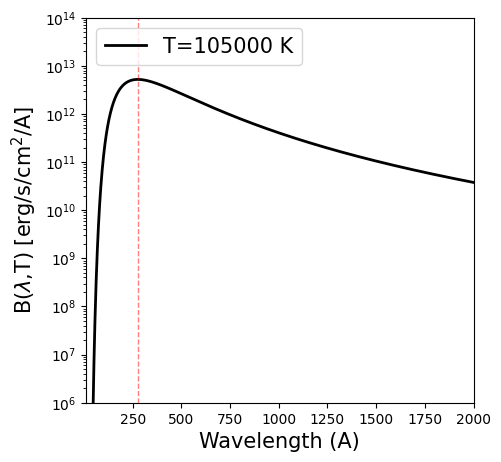

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(5, 5))
h = const.h.value    #  J*s           
kb = const.k_B.value      # J/K
T = 1.05e5              # K
c_ms = const.c.value # m/s
lambda_A = np.linspace(1, 5000, 5000) # 파장: 1~1000 a
lambda_m = lambda_A * 1e-10            # m 단위 변환

B = (2*h*c_ms**2) / (lambda_m**5) / (np.exp(h*c_ms/(lambda_m*kb*T))-1)
B_erg = B*1e-7 # erg/cm^2/s/A
peak_lam = 2.898e-3 / T   # m
print("Peak lambda_Wine's law = ",peak_lam*1e10,"A")
E_peak = const.h.to(u.eV * u.s).value * c_ms  / peak_lam
print("Peak Energy",E_peak, "eV")

plt.plot(lambda_A, B_erg,'k-',linewidth=2,label=f"T={T:.0f} K")
plt.xlabel('Wavelength (A)',fontsize=15)
plt.ylabel('B($\lambda$,T) [erg/s/cm$^2$/A]',fontsize=15)

plt.axvline(x=peak_lam*1e10,color='r',linestyle='--',linewidth=1,alpha=0.5)
# plt.axvline(x=1550.772,color='b',linestyle='--',linewidth=1,alpha=0.5)

plt.xlim(10, 2000)
plt.ylim(1e6, 1e14)
plt.yscale('log')
plt.legend(fontsize=15,loc='upper left')

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Planck_Distribution.png', bbox_inches='tight')


In [4]:

rr = np.arange(13, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

lam_c =  (C_IV_K_A + C_IV_H_A) / 2

voigt_path_11_8 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
voigt_path_30 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
voigt_path_50 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'

NN = int(1e4)


C_IV_N = np.linspace(1e12, 1e17, NN)

def N_esc_scat(line,voigt_path,v_th):


    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)
    lam_0, scat_0 = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam_0-C_IV_K) / C_IV_K) * cc /1e5
    x =   del_V / (v_th/1e5)
    K_H_center = 250  / (v_th/1e5)
    dx = x[1] - x[0]
    x_K = x[np.where(x <= K_H_center)[0]]
    x_H = x[np.where(x >= K_H_center)[0]]
    scat_K = scat_0[np.where(x <= K_H_center)[0]]
    scat_H = scat_0[np.where(x >= K_H_center)[0]]
    x_0 = np.zeros(NN)

    xx_K = 0
    xx_H = 500/ (v_th/1e5)

    if line =='K' or line =='k' :
        x = x_K
        scat = scat_K
        xx_c = xx_K
        ii = np.where( (x > -dx/2) & (x < dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[ii]) ,1/scat[ii]

    elif line == 'H' or line =='h' :
        x = x_H 
        scat = scat_H
        xx_c = xx_H
        jj = np.where( (x > xx_H -dx/2) & (x < xx_H +dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[jj]) ,1/scat[jj]



    tau_profile = np.outer(C_IV_N, scat)
    
    # print(line,'scattering cross-section = ', cross_sec_cen )
    print(line,'Center  Columne density = ', N_CIV_cen  )


    for ii, jj in enumerate(C_IV_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = x[x_p].max() if x_p.size > 0 else 0


    V_del_peak = 2*abs( (x_0 - xx_c)*(v_th/1e5))

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    # V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    
    return x ,tau_profile , V_del_peak , N_esc


def calculate_order_and_value(value):

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def data_sp_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy() # total photon
    spec_sc = data[2].to_numpy()  # scattering photon
   # spec_pol_tot = data[3]  # polization of the total photon
   # spec_pol_scat = data[4]  $ polization of the scattering photon
    return lam , spec_tot , spec_sc



#separate K and H line
def data_sp(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  data_sp_com(Line , atom_num , atom_index, vout, vemit, vran)
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = data_sp_com(Line, atom_num, atom_index, vout, vemit, vran)

    # 모든 피크 찾기
    peaks, properties = find_peaks(spec_halo)

    if len(peaks) < 2:
        # 피크가 2개 미만이면 del_v = 0
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # 모든 피크 중 강도 높은 상위 2개 선택
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
        top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

        # 피크 파장 및 강도
        peak_lambda = lam[top_2_indices]
        peak_values = spec_halo[top_2_indices]

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
        if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
            del_v = 0
        else:
            # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

    return del_v, peak_lambda



def doublet_ratio(Line, atom_num, atom_index, vout, vemit, vran):
    lam_K , spec_tot_K , spec_halo_K = K_H_from_Combine_data('k', atom_num, atom_index, vout, vemit, vran)
    lam_H , spec_tot_H , spec_halo_H = K_H_from_Combine_data('h', atom_num, atom_index, vout, vemit, vran)

    lam_c =  (C_IV_K_A + C_IV_H_A) / 2 

    cut_off_K = np.where(lam_K >= C_IV_K_A + (C_IV_K_A-lam_c) )[0] # >= C_IV_K_A + (C_IV_K_A-lam_c)
    cut_off_H = np.where(lam_H <= C_IV_H_A + abs(C_IV_H_A-lam_c))[0] # <= C_IV_H_A + abs(C_IV_H_A-lam_c)


    cut_spec_tot_K = spec_tot_K[cut_off_K]
    cut_spec_tot_H = spec_tot_H[cut_off_H]

    doublet_line_ratio = np.sum(cut_spec_tot_K) / np.sum(cut_spec_tot_H)

    # doublet_line_ratio = np.sum(spec_tot_K) / np.sum(spec_tot_H)
    return doublet_line_ratio


def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel



def tau_0(Line, atom_num, atom_index, vout, vemit, vran):
    if Line == 'h' or Line =='H':
        f_c = f_CIV_H

    elif Line == 'k' or Line =='K':
        f_c = f_CIV_K
    T = 1e5
    M = 12
    N_t = (atom_num/10) * 10**(atom_index)
    tau = 1.9 * (f_c / 0.4164) * (T/1e5)**(-0.5) * (M)**(0.5) * (N_t /10**14)
    return tau

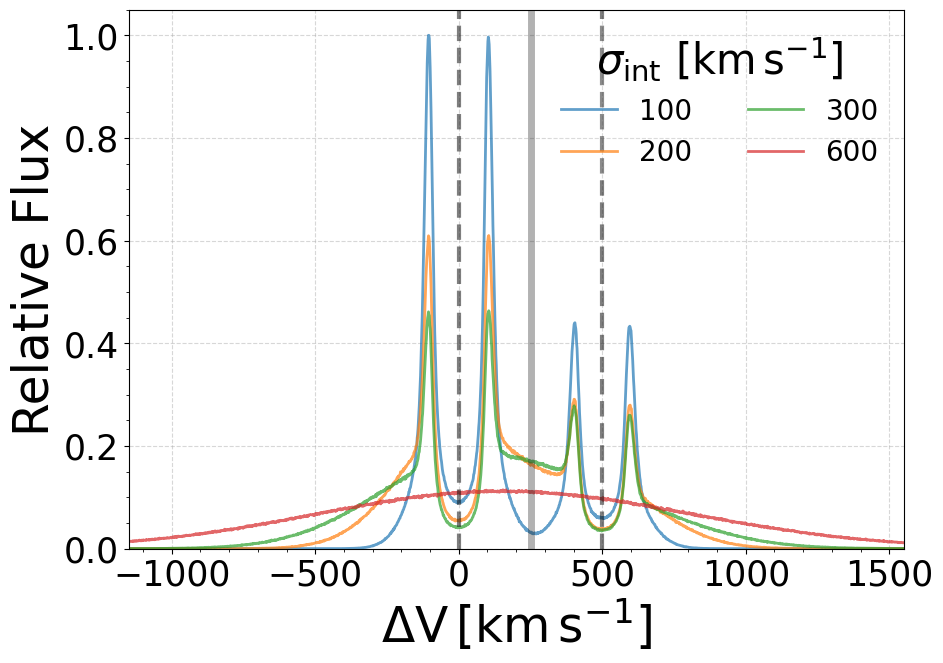

In [47]:
import math
fig = plt.figure(1,figsize=(10,7))

# plt.subplot(121)

atom_num,  vout,vemit,vran = 10 , 000, 100,50
index = 16
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')

vemit = 200
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')

vemit = 300
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')

vemit = 600
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')



# vemit = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=4,alpha=0.7,label=f'{vemit}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)

plt.xlim(-1150, 1550)
plt.ylim(ymin=0.0)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=35)
plt.ylabel(r'Relative Flux',fontsize=35)


# plt.legend(title = r'$\sigma_{\rm int}~[\rm km\,s^{-1}]$',title_fontsize=35,fontsize=20,frameon=False)

leg = plt.legend(
    fontsize=20, 
    title = r'$\sigma_{\rm int}~[\rm km\,s^{-1}]$',
    title_fontsize=30,
    ncol=2,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)


# plt.subplot(122)

# analy_emit = np.linspace(1,650,100)

# def analy_doublet_ratio(vemit):
#     aa = 250/np.sqrt(2)/vemit
#     bb = 750/np.sqrt(2)/vemit
#     kk = 3*special.erf(aa) +special.erf(bb)
#     hh = 2*special.erf(bb)
#     ratio = kk/ hh
#     return ratio 

# # tt =  doublet_ratio(emit)
# yy = analy_doublet_ratio(analy_emit)
# # tt


# atom, index, vout, vran = 10 , 12 ,000, 11.8


# Vemit = np.array([1,50,100,200,300,400,500,600])

# ratio = np.zeros(len(Vemit))
# for ii, vemit in enumerate(Vemit):
#     ratio[ii] = doublet_ratio('all',atom,index,vout,vemit,vran)




# plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)
# plt.plot(analy_emit,yy,'k--',lw=5,alpha=0.5,label='Analytic solution')
# plt.plot(Vemit, ratio,'o',mec='k',mfc='r',ms=15,lw=3,label='RT simulation')


# plt.xlabel(r'$\sigma_{\rm int} ~[\rm km \, s^{-1}]$ ',fontsize=35)
# plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=35)


# plt.xlim(-10,615)
# plt.ylim(0.9,2.1)


# plt.xticks(fontsize=25)
# plt.yticks([1.0,1.2,1.4,1.6,1.8,2.0],fontsize=25)




# plt.minorticks_on()
# plt.grid(True,linestyle='--',alpha=0.5)
# plt.legend(bbox_to_anchor=(0.475,0.5557),fontsize=25,frameon=False)
# plt.tight_layout()





# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_doublet_instinsic_RT.pdf', bbox_inches='tight')
# 

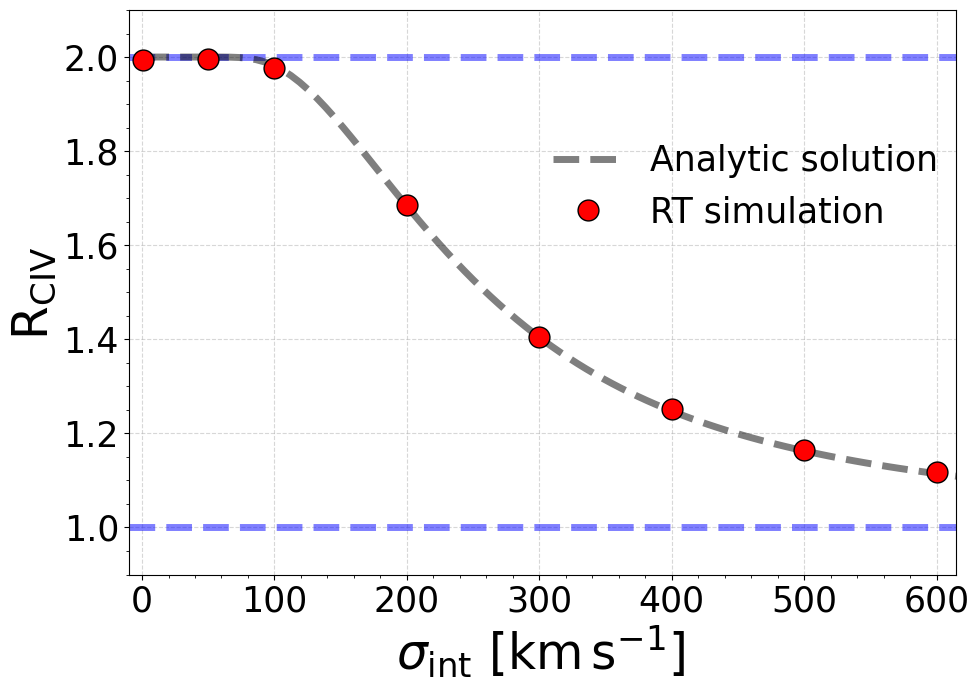

In [6]:
import math
fig = plt.figure(1,figsize=(10,7))


analy_emit = np.linspace(1,650,100)

def analy_doublet_ratio(vemit):
    aa = 250/np.sqrt(2)/vemit
    bb = 750/np.sqrt(2)/vemit
    kk = 3*special.erf(aa) +special.erf(bb)
    hh = 2*special.erf(bb)
    ratio = kk/ hh
    return ratio 

# tt =  doublet_ratio(emit)
yy = analy_doublet_ratio(analy_emit)
# tt


atom, index, vout, vran = 10 , 12 ,000, 11.8


Vemit = np.array([1,50,100,200,300,400,500,600])

ratio = np.zeros(len(Vemit))
for ii, vemit in enumerate(Vemit):
    ratio[ii] = doublet_ratio('all',atom,index,vout,vemit,vran)




plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)
plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)
plt.plot(analy_emit,yy,'k--',lw=5,alpha=0.5,label='Analytic solution')
plt.plot(Vemit, ratio,'o',mec='k',mfc='r',ms=15,lw=3,label='RT simulation')


plt.xlabel(r'$\sigma_{\rm int} ~[\rm km \, s^{-1}]$ ',fontsize=35)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=35)


plt.xlim(-10,615)
plt.ylim(0.9,2.1)


plt.xticks(fontsize=25)
plt.yticks([1.0,1.2,1.4,1.6,1.8,2.0],fontsize=25)




plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
plt.legend(bbox_to_anchor=(0.475,0.5557),fontsize=25,frameon=False)
plt.tight_layout()





# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_doublet_ratio_instinsic_RT.pdf', bbox_inches='tight')
# 

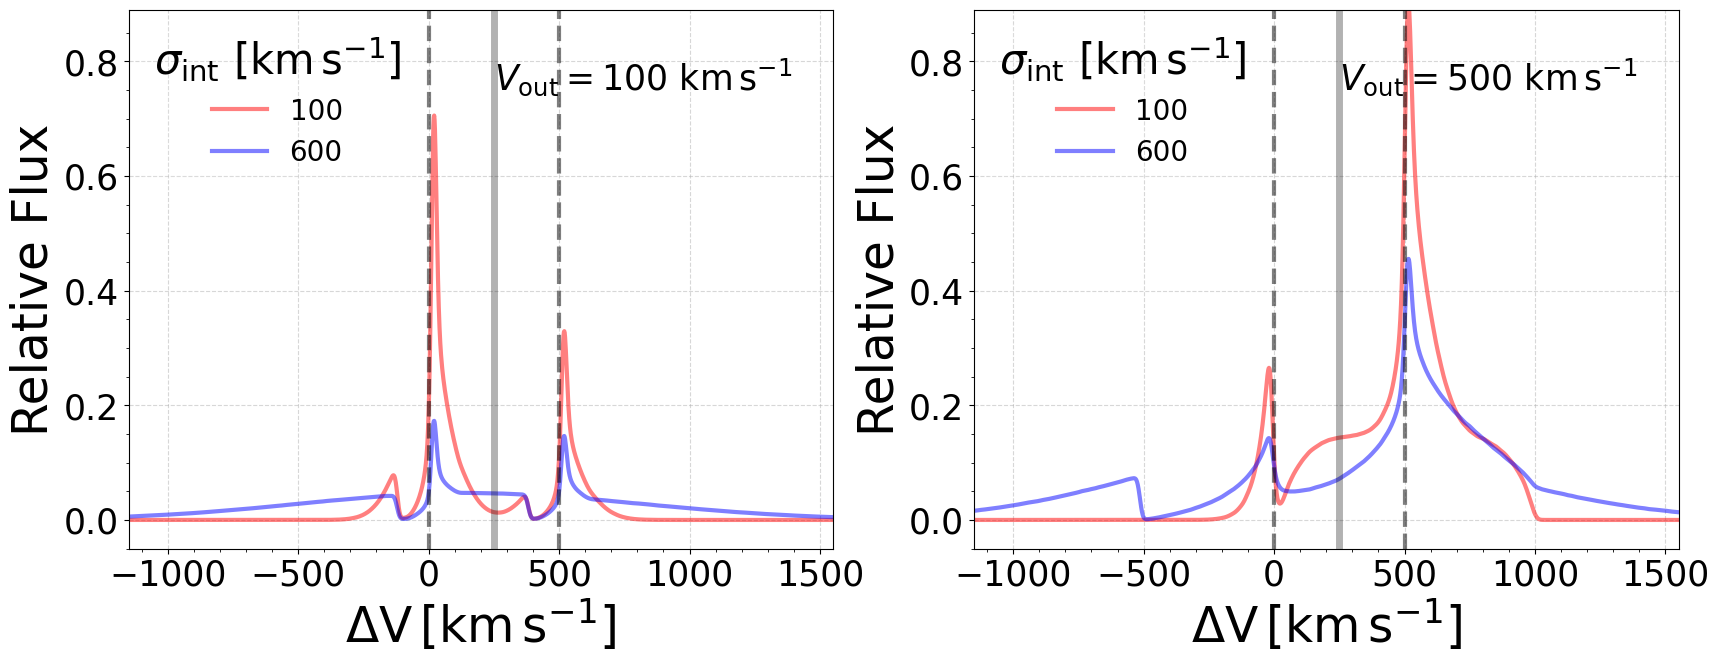

In [7]:
import math
fig = plt.figure(1,figsize=(20,7))

plt.subplot(121)


N = 3000
from scipy.interpolate import interp1d

# 200,300,
N_vemit= np.array([100,600]) 
atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
index = 16
color = ['r','b']
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
for i, vemit in enumerate(N_vemit):
    lam, flux = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[:2]
    xx = np.linspace(lam.min(),lam.max(),N)
    yy_inp = interp1d(lam, flux, bounds_error=False, fill_value=0)
    plt.plot(lam_to_vel(xx), gaussian_filter1d(yy_inp(xx)/normal,sigma=5),'-',color=color[i],lw=3,alpha=0.5,label=f'{vemit}')

plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)

plt.xlim(-1150, 1550)
plt.ylim(ymin=-0.05)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=35)
plt.ylabel(r'Relative Flux',fontsize=35)

plt.text(x=250, y=0.75, s=fr'$V_{{\rm out}} = {vout}~{{\rm km\,s^{{-1}}}}$', fontsize=25, fontweight='bold')

# plt.legend(title = r'$\sigma_{\rm int}~[\rm km\,s^{-1}]$',title_fontsize=35,fontsize=20,frameon=False)

leg = plt.legend(
    fontsize=20, 
    title = r'$\sigma_{\rm int}~[\rm km\,s^{-1}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
plt.ylim(ymax=0.89)

plt.subplot(122)

atom_num,  vout,vemit,vran = 10 , 500, 100,11.8
index = 16
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

for i, vemit in enumerate(N_vemit):
    lam, flux = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[:2]
    xx = np.linspace(lam.min(),lam.max(),N)
    yy_inp = interp1d(lam, flux, bounds_error=False, fill_value=0)
    plt.plot(lam_to_vel(xx), gaussian_filter1d(yy_inp(xx)/normal,sigma=5),'-',color=color[i],lw=3,alpha=0.5,label=f'{vemit}')


# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')

# # vemit = 200
# # plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')

# vemit = 300
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')

# vemit = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=2,alpha=0.7,label=f'{vemit}')



# vemit = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',lw=4,alpha=0.7,label=f'{vemit}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)

plt.xlim(-1150, 1550)
plt.ylim(ymin=-0.05)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=35)
plt.ylabel(r'Relative Flux',fontsize=35)


# plt.legend(title = r'$\sigma_{\rm int}~[\rm km\,s^{-1}]$',title_fontsize=35,fontsize=20,frameon=False)

leg = plt.legend(
    fontsize=20, 
    title = r'$\sigma_{\rm int}~[\rm km\,s^{-1}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
plt.ylim(ymax=0.89)

plt.text(x=250, y=0.75, s=fr'$V_{{\rm out}} = {vout}~{{\rm km\,s^{{-1}}}}$', fontsize=25, fontweight='bold')



plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Spectrum_Gaussian_doublet_instinsic_RT_with_outflow.pdf', bbox_inches='tight')
# 

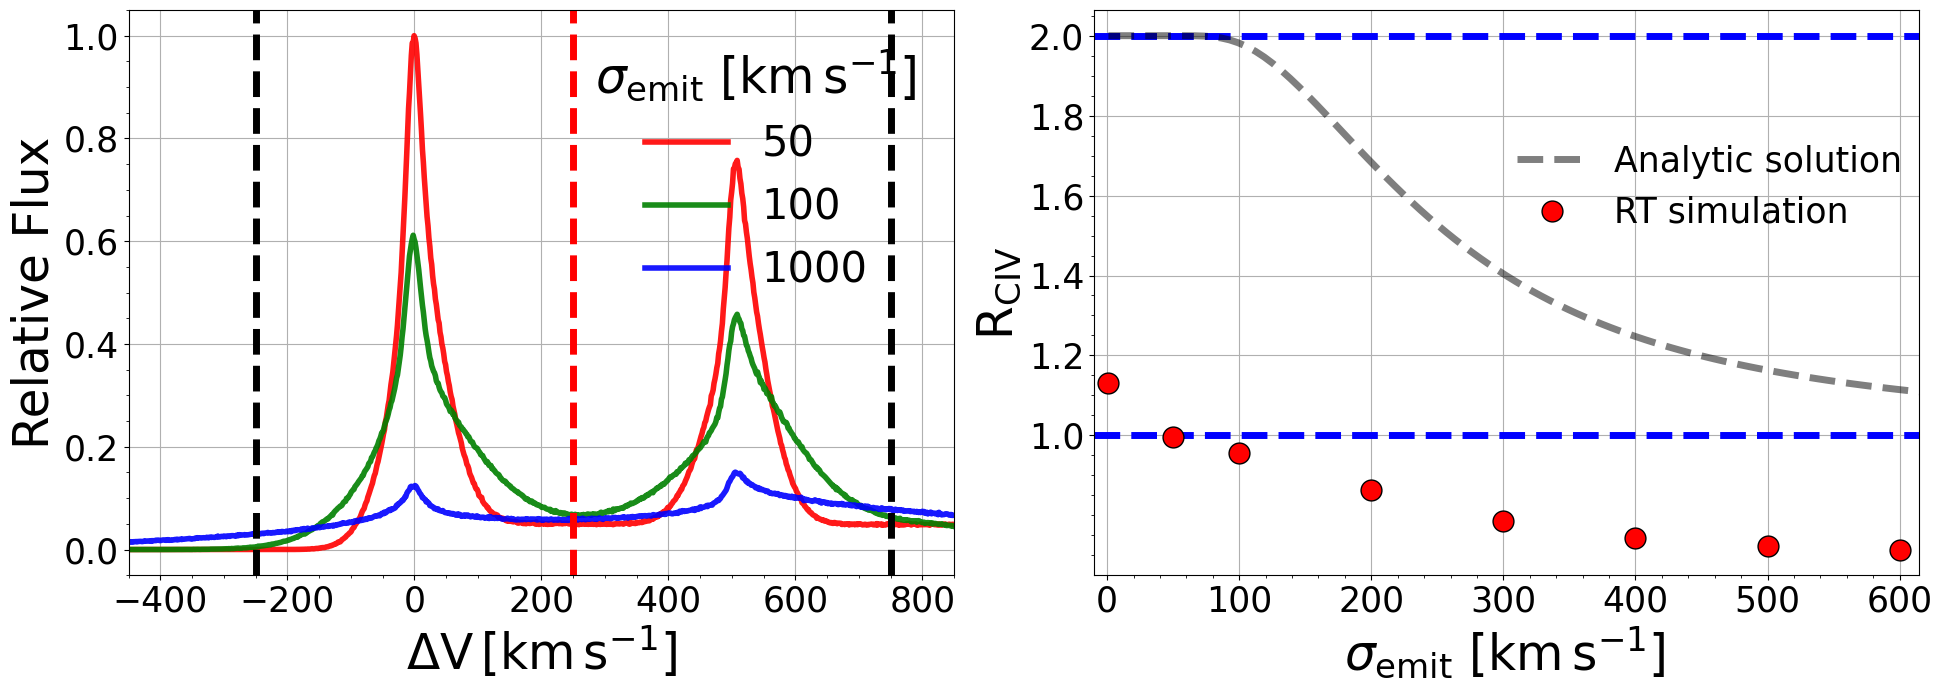

In [8]:
import math
fig = plt.figure(1,figsize=(20,7))

plt.subplot(121)

atom_num,  vout,vemit,vran = 10 , 500, 50,11.8
index = 15
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'r-',lw=4,alpha=0.9,label=f'{vemit}')

vemit = 100
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'g-',lw=4,alpha=0.9,label=f'{vemit}')

vemit = 1000
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.9,label=f'{vemit}')


plt.axvline(x=250,ymin=0,ymax=5,color='r',linestyle='--',lw = 5)
plt.axvline(x=-250,ymin=0,ymax=5,color='k',linestyle='--',lw = 5)
plt.axvline(x=750,ymin=0,ymax=5,color='k',linestyle='--',lw = 5)

plt.xlim(-450, 850)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=35)
plt.ylabel(r'Relative Flux',fontsize=35)


plt.legend(title = r'$\sigma_{\rm emit}~[\rm km\,s^{-1}]$',title_fontsize=35,fontsize=30,frameon=False)
plt.minorticks_on()
plt.grid(True)


plt.subplot(122)

analy_emit = np.linspace(1,650,100)

def analy_doublet_ratio(vemit):
    aa = 250/np.sqrt(2)/vemit
    bb = 750/np.sqrt(2)/vemit
    kk = 3*special.erf(aa) +special.erf(bb)
    hh = 2*special.erf(bb)
    ratio = kk/ hh
    return ratio 

# tt =  doublet_ratio(emit)
yy = analy_doublet_ratio(analy_emit)
# tt


atom, index, vout, vran = 10 , 15 ,500, 11.8


Vemit = np.array([1,50,100,200,300,400,500,600])

ratio = np.zeros(len(Vemit))
for ii, vemit in enumerate(Vemit):
    ratio[ii] = doublet_ratio('all',atom,index,vout,vemit,vran)




plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5)
plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5)
plt.plot(analy_emit,yy,'k--',lw=5,alpha=0.5,label='Analytic solution')
plt.plot(Vemit, ratio,'o',mec='k',mfc='r',ms=15,lw=3,label='RT simulation')


plt.xlabel(r'$\sigma_{\rm emit} ~[\rm km \, s^{-1}]$ ',fontsize=35)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=35)


plt.xlim(-10,615)
# plt.ylim(0.9,2.1)


plt.xticks(fontsize=25)
plt.yticks([1.0,1.2,1.4,1.6,1.8,2.0],fontsize=25)




plt.minorticks_on()
plt.grid(True)
plt.legend(bbox_to_anchor=(0.475,0.5557),fontsize=25,frameon=False)
plt.tight_layout()





# plt.savefig('/home/jin/바탕화면/Gaussian_doublet_instinsic_RT.pdf')


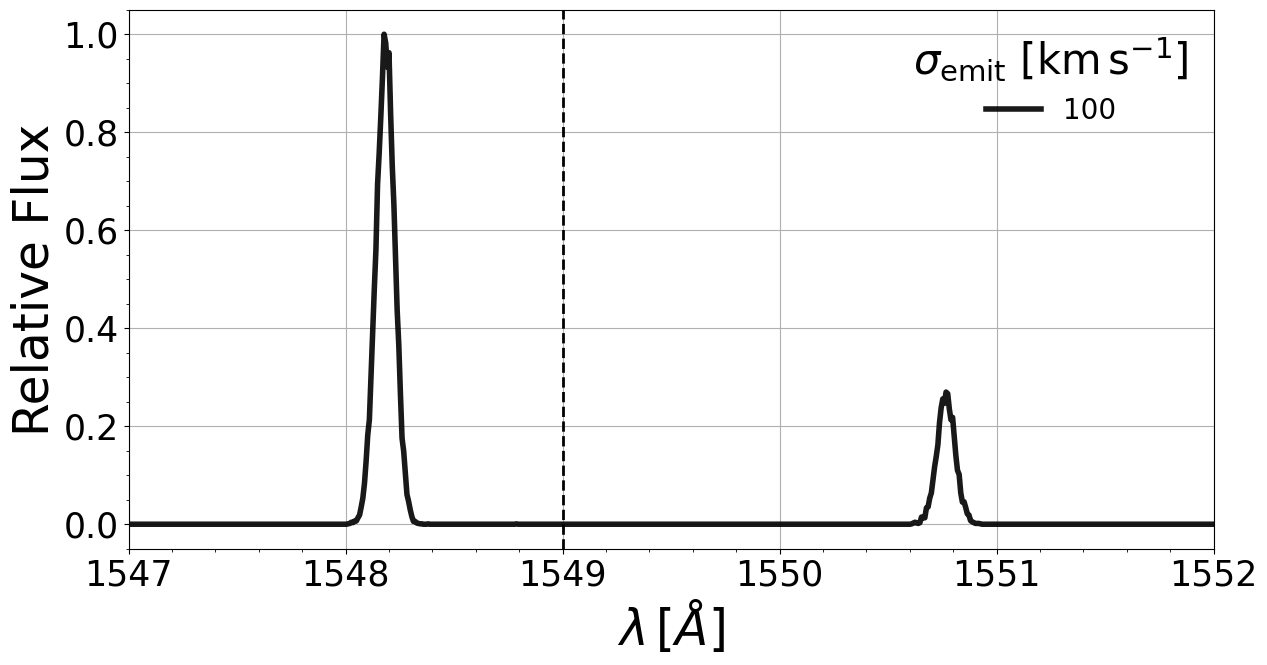

In [9]:
fig = plt.figure(1,figsize=(14,7))
atom_num,  vout,vemit,vran = 10 , 000, 100,11.8
vemit = 100
index = 12
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2].sum()

plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2].max(),'k-',lw=4,alpha=0.9,label=f'{vemit}')


# plt.axvline(x=250,ymin=0,ymax=5,color='r',linestyle='--',lw = 2)
# plt.axvline(x=-250,ymin=0,ymax=5,color='k',linestyle='--',lw = 2)
plt.axvline(x=1549,ymin=0,ymax=5,color='k',linestyle='--',lw = 2)

# plt.xlim(1546, 1550)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)


plt.xlabel(r'$\lambda \, [\AA]$',fontsize=35)
plt.ylabel(r'Relative Flux',fontsize=35)

plt.xlim(1547,1552)

plt.legend(title = r'$\sigma_{\rm emit}~[\rm km\,s^{-1}]$',title_fontsize=30,fontsize=20,frameon=False)
plt.minorticks_on()
plt.grid(True)


In [10]:
# data = pd.read_csv('/home/jin/RT/RT_main/NGC_6302_v2.txt',sep='\,')
# data_x = data['wave'].to_numpy()
# data_y = data[' flux'].to_numpy()

# # ioc = np.where((data_x > 6300) & (data_x < 6800)) 

# plt.plot(data_x,data_y/1e-15)
# plt.xlim(7075, 7100)
# plt.ylim(0.4,1.2)
# atom_num,  vout,vemit,vran = 13, 000, 50, 50
# vemit = 1
# index = 15

# x = K_H_from_Combine_data('K',atom_num,index, vout,vemit,vran)[0]
# y = K_H_from_Combine_data('K',atom_num,index, vout,vemit,vran)[2]

# loc = np.where((x>=1548) & (x<=1550))

# # plt.plot( x_loc,y_loc/normal,'b-',lw=4,alpha=0.9,label=f'{vemit}')
# x_loc = x[ioc]
# y_loc= y[ioc]
# normal = np.sum(y_loc)
# fc = data_y.max()
# plt.plot( (x_loc - 1548)*7 + 6826, ((y_loc/normal)*18)+0.70 ,'b-',lw=4,alpha=0.9,label=f'{vemit}')
# plt.plot(data_x,data_y/1e-15)
# plt.xlim(6810, 6840)
# # plt.xlim(7075, 7100)
# plt.ylim(0.4,1.2)


1.0000018633265861


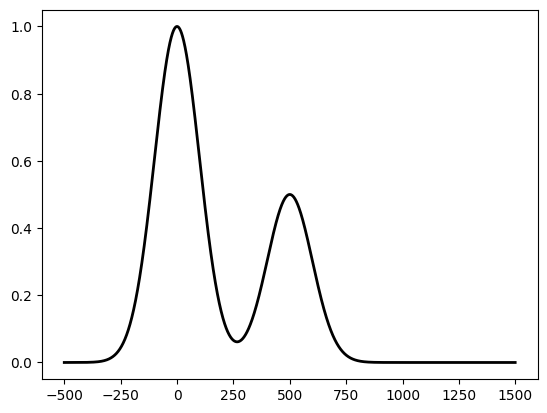

In [11]:
atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'-',color='k',lw=2,alpha=1)

print(yy.max())

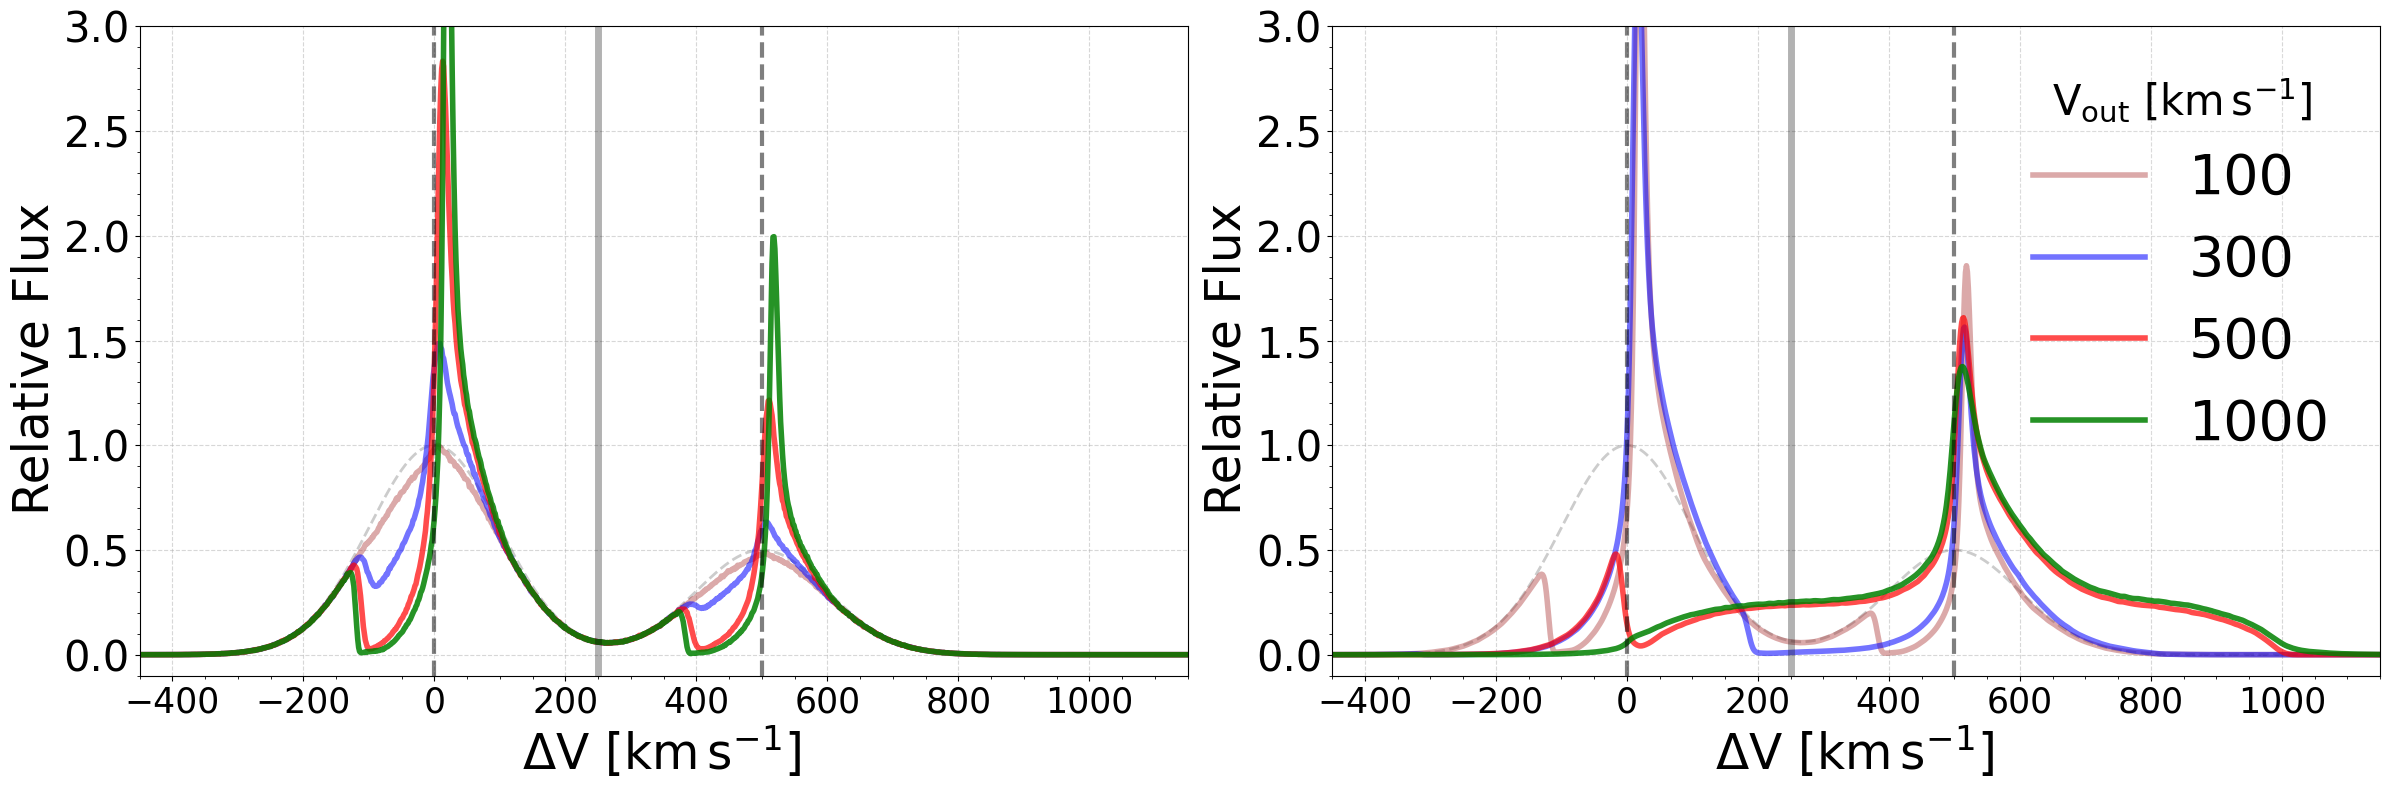

In [12]:
fig = plt.figure(1,figsize=(24,8))


plt.subplot(121)
atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2,alpha=0.2)


color =  ['brown', 'b', 'r', 'g']
# import seaborn as sns

# color = sns.color_palette("bright", n_colors=4)

lw = 4
alpha = 0.6

# lw = 3
# alpha = 0.7
N_index= np.arange(13,17,1)
index = 13
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

for i, index in enumerate(N_index) :
    alpha = 0.4 + 0.6*(i/len(N_index))
    plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[i],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 13
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'y-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')

# index = 14
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[1],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 15
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[2],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 16
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[3],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 17
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'brown-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')


plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)


plt.xlim(-450,1150)
plt.ylim(ymin=-0.1,ymax=3.0)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=30)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)

# leg = plt.legend(
#     fontsize=40, 
#     title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',
#     title_fontsize=30,
#     ncol=1,
#     frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()

plt.subplot(122)


atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2,alpha=0.2)

atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
index = 16

# normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.25,label=f'{vout}')

# vout = 100
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.2,label=f'{vout}')

# vout = 300
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.5,label=f'{vout}')

# vout = 500
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=4,alpha=0.5,label=f'{vout}')

# vout = 1000
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=4,alpha=1,label=f'{vout}')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm


# vout_values = [100, 200,400, 500, 1000]
vout_values = [100,300,500,1000]
# cmap = cm.get_cmap('Reds')

# colormap 범위 조절: 0.3 ~ 1.0 사이에서 색 뽑기
vmin, vmax = 0.4, 1.0
# color = np.array(['r','orange','crimson','brown'])


# N = 300000
# from scipy.interpolate import interp1d

# for i, vout in enumerate(vout_values):
#     # t = i / (len(vout_values) - 1)  # 0~1 사이 정규화
#     # color = cmap(vmin + (vmax - vmin) * t)  # 밝은 색은 피함
#     lam, flux = K_H_from_Combine_data('all', atom_num, index, vout, vemit, vran)[:2]
#     xx_lam = np.linspace(lam.min(),lam.max(),N)
#     yy_interpol = interp1d(lam, flux, bounds_error=False, fill_value=0)
#     if vout == 300:
#     #     color = 'red'
#         alpha = 1.0
#     else : alpha = 0.7
#     plt.plot(
#         lam_to_vel(xx_lam),
#         yy_interpol(xx_lam) / normal,
#         # color=color[i],
#         lw=lw,
#         alpha= alpha ,
#         label=f'{vout}'
#     )


# N = 300000


for i, vout in enumerate(vout_values):
    # t = i / (len(vout_values) - 1)  # 0~1 사이 정규화
    # color = cmap(vmin + (vmax - vmin) * t)  # 밝은 색은 피함
    lam, flux = K_H_from_Combine_data('all', atom_num, index, vout, vemit, vran)[:2]
    # xx_lam = np.linspace(lam.min(),lam.max(),N)
    yy_smooth = gaussian_filter1d(flux, sigma=2)
    # if vout == 1000:
    # #     color = 'red'
    #     alpha = 1.0
    # else : alpha = 0.6
    alpha = 0.4 + 0.6*(i/len(vout_values))
    plt.plot(
        lam_to_vel(lam),
        yy_smooth / normal,
        color=color[i],
        lw=lw,
        alpha= alpha ,
        label=f'{vout}'
    )



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=5,color='k',linestyle='-',lw = 5,alpha=0.3)

plt.xlim(-450,1150)
plt.ylim(ymin=-0.1,ymax=3.0)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=30)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$ \rm V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=40,fontsize=35,frameon=False)

leg = plt.legend(
    fontsize=40, 
    title=r'$ \rm V_{\rm out}~[\rm km \, s^{-1}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')


plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)


# plt.text(50,1.75,s=r'V$_{\rm out} = 600~[\rm km\, s^{-1}]$',size=20)

# plt.subplot(133)

# rr = np.arange(12, 17, 1)
# atom = [13,20,32,50,79]
# rr_reshaped = rr.reshape(-1, 1)
# total_N_c = 10**rr_reshaped * atom / 10
# total_N_c = total_N_c.flatten()
# vemit,vran =100,11.8
# V = np.arange(0,1200,200)
# for jj, vout in enumerate(V):
#     ratio = np.zeros(len(total_N_c))
#     for ii, N_civ in enumerate(total_N_c):
#         index = math.floor(math.log10(N_civ))
#         atom_n = int(N_civ/ 10**index*10)
#         ratio[ii] = doublet_ratio('all',atom_n,index,vout,vemit,vran)
#     plt.plot(total_N_c,ratio,'-o',label=f'{vout}')
#     plt.xscale('log')
        

# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


# # plt.axhline(y=0.25, xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

# plt.legend(fontsize=25, title=r'$V_{\rm out} ~ [\rm km\, s^{-1}]$',title_fontsize=30,ncol=2,frameon=False)

# plt.xticks(fontsize=25)
# plt.xlabel(r'$ N_{\rm CIV} ~[\rm cm^{-2}]$ ',fontsize=30)
# plt.xlim(2e12,5e16)

# plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=25)
# plt.ylim(-0.1,2.4)
# plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
# plt.minorticks_on()
# plt.grid(True)



plt.tight_layout()


# plt.savefig('/home/jin/바탕화면/Gaussian_300_600_velocity.pdf', bbox_inches='tight')
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_300_600_velocity', bbox_inches='tight')

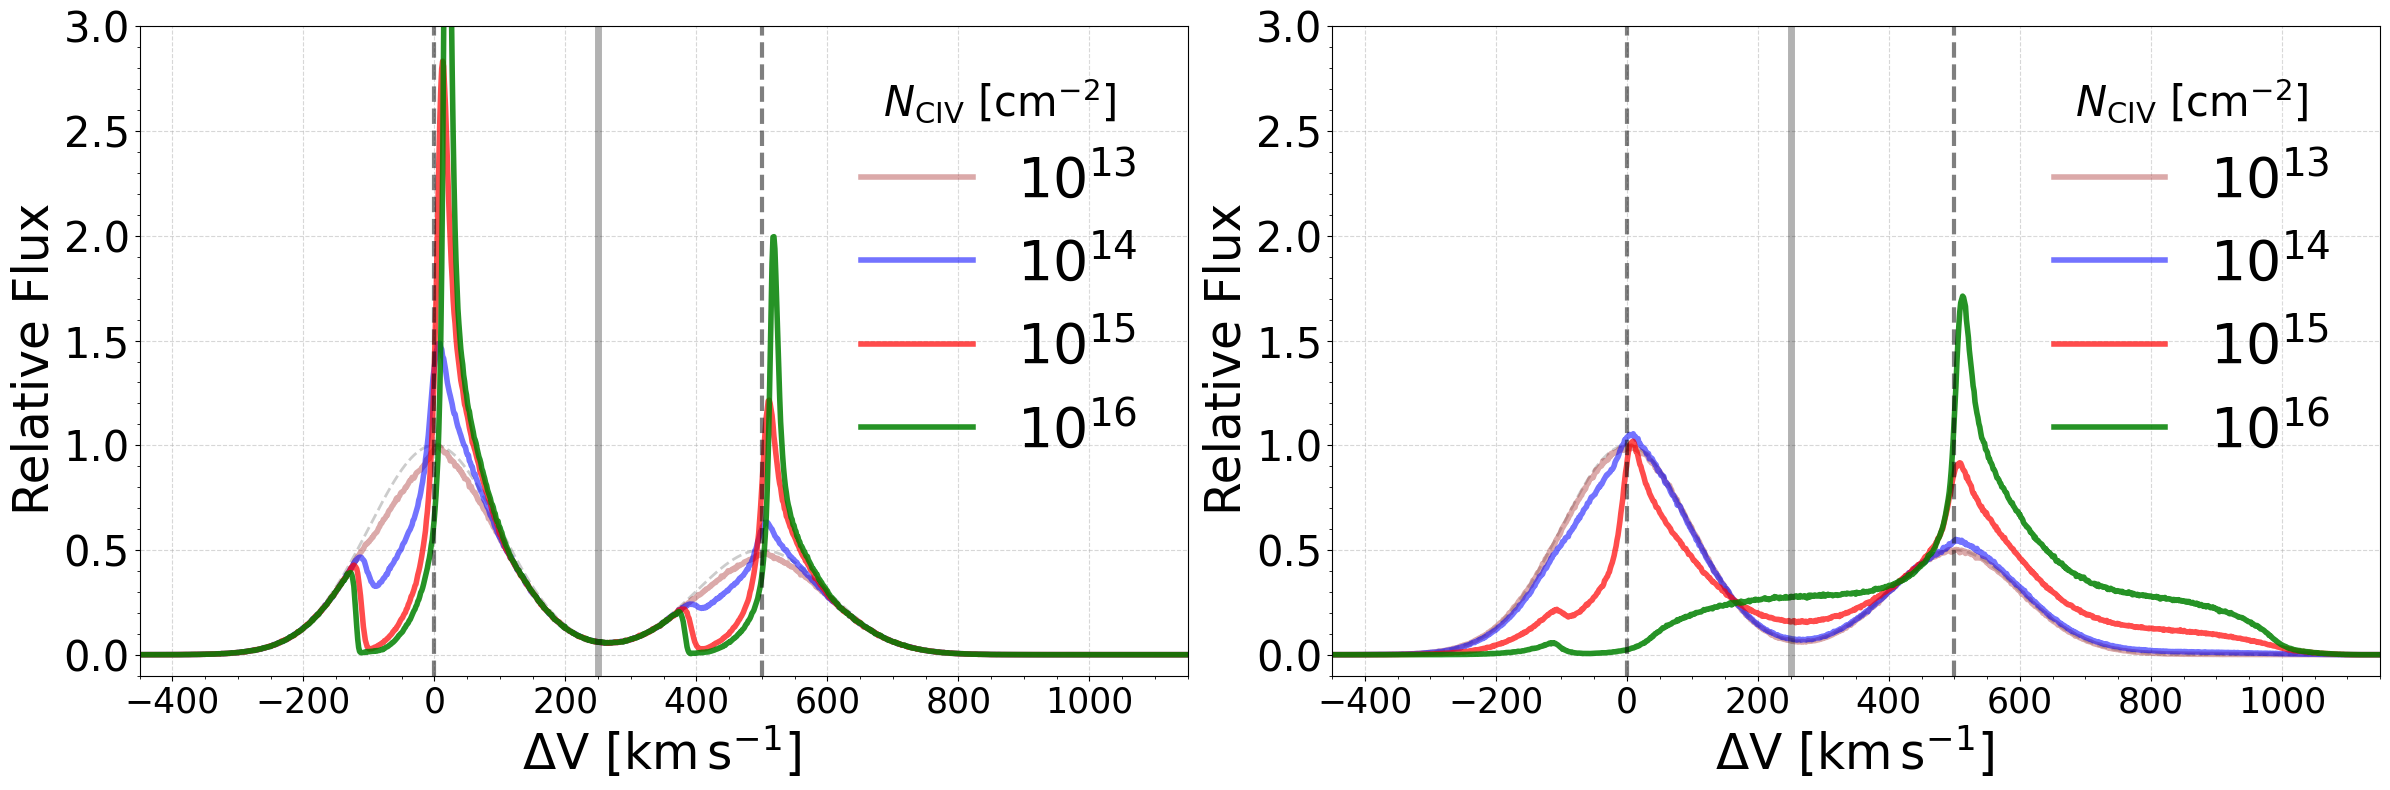

In [13]:
fig = plt.figure(1,figsize=(24,8))


plt.subplot(121)
atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2,alpha=0.2)


color =  ['brown', 'b', 'r', 'g']
# import seaborn as sns

# color = sns.color_palette("bright", n_colors=4)

lw = 4
alpha = 0.6

# lw = 3
# alpha = 0.7
N_index= np.arange(13,17,1)
index = 13
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

for i, index in enumerate(N_index) :
    alpha = 0.4 + 0.6*(i/len(N_index))
    plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[i],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 13
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'y-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')

# index = 14
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[1],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 15
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[2],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 16
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[3],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 17
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'brown-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')


plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)


plt.xlim(-450,1150)
plt.ylim(ymin=-0.1,ymax=3.0)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=30)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)

leg = plt.legend(
    fontsize=40, 
    title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()

plt.subplot(122)


atom_num,  vout,vemit,vran = 10 , 600, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2,alpha=0.2)


color =  ['brown', 'b', 'r', 'g']
# import seaborn as sns

# color = sns.color_palette("bright", n_colors=4)

lw = 4
alpha = 0.6

# lw = 3
# alpha = 0.7
N_index= np.arange(13,17,1)
index = 13
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

for i, index in enumerate(N_index) :
    alpha = 0.4 + 0.6*(i/len(N_index))
    plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[i],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 13
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'y-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')

# index = 14
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[1],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 15
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[2],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 16
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[3],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 17
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'brown-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')


plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)


plt.xlim(-450,1150)
plt.ylim(ymin=-0.1,ymax=3.0)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=30)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)

leg = plt.legend(
    fontsize=40, 
    title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()

plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_300_600_velocity', bbox_inches='tight')

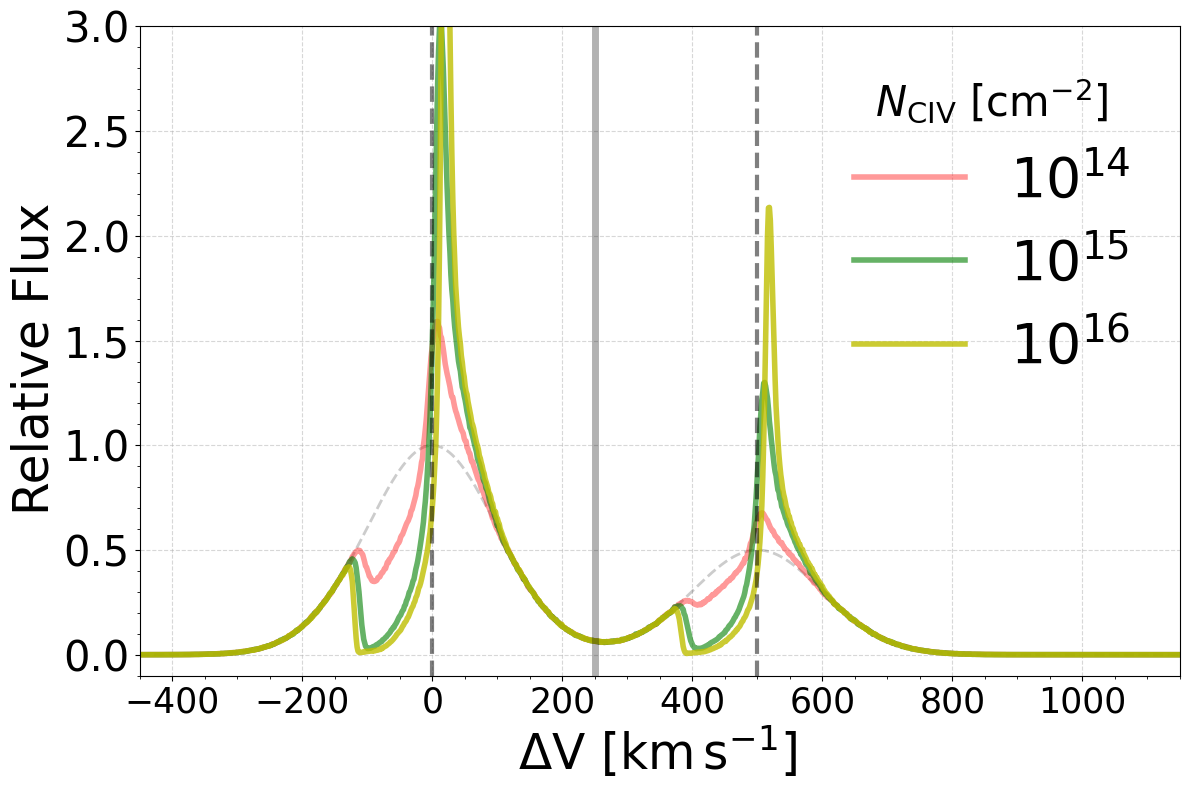

In [14]:
fig = plt.figure(1,figsize=(12,8))


atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2,alpha=0.2)


color =  ['r', 'g','y'] # 'brown', 'b', 
# color =  ['brown', 'b', ] 
# import seaborn as sns

# color = sns.color_palette("bright", n_colors=4)

lw = 4
alpha = 0.6

# lw = 3
# alpha = 0.7
N_index= np.arange(14,17,1)
index = 12
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

for i, index in enumerate(N_index) :
    alpha = 0.4 + 0.6*(i/len(N_index))
    plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[i],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 13
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'y-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')

# index = 14
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[1],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 15
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[2],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 16
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'-',color=color[3],lw=lw,alpha=alpha,label=f'$10^{{{index}}}$')

# index = 17
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'brown-',lw=5,alpha=1.0,label=f'$10^{{{index}}}$')


plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=1,color='k',linestyle='-',lw = 5,alpha=0.3)


plt.xlim(-450,1150)
plt.ylim(ymin=-0.1,ymax=3.0)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=30)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)

leg = plt.legend(
    fontsize=40, 
    title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')

plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()



plt.tight_layout()


# plt.savefig('/home/jin/바탕화면/Gaussian_300_600_velocity.pdf', bbox_inches='tight')
plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/figure2', bbox_inches='tight')

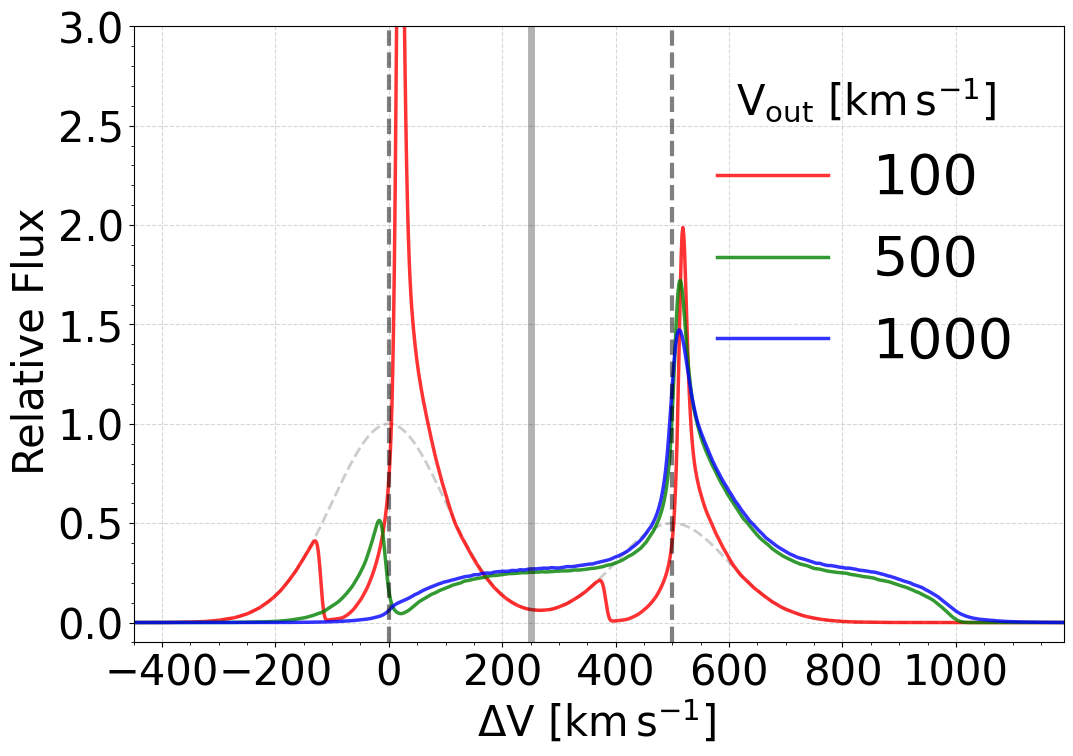

In [15]:
fig = plt.figure(1,figsize=(12,8))
atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
xx = np.arange(-500,1500,0.5)
aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2,alpha=0.2)

atom_num,  vout,vemit,vran = 10 , 100, 100,11.8
index = 16

# normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.25,label=f'{vout}')

# vout = 100
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.2,label=f'{vout}')

# vout = 300
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.5,label=f'{vout}')

# vout = 500
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=4,alpha=0.5,label=f'{vout}')

# vout = 1000
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=4,alpha=1,label=f'{vout}')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm


# vout_values = [100, 200,400, 500, 1000]
vout_values = [100,500,1000]
# cmap = cm.get_cmap('Reds')

# colormap 범위 조절: 0.3 ~ 1.0 사이에서 색 뽑기
vmin, vmax = 0.6, 1.0
# color = np.array(['r','orange','crimson','brown'])


# N = 300000
# from scipy.interpolate import interp1d

# for i, vout in enumerate(vout_values):
#     # t = i / (len(vout_values) - 1)  # 0~1 사이 정규화
#     # color = cmap(vmin + (vmax - vmin) * t)  # 밝은 색은 피함
#     lam, flux = K_H_from_Combine_data('all', atom_num, index, vout, vemit, vran)[:2]
#     xx_lam = np.linspace(lam.min(),lam.max(),N)
#     yy_interpol = interp1d(lam, flux, bounds_error=False, fill_value=0)
#     if vout == 300:
#     #     color = 'red'
#         alpha = 1.0
#     else : alpha = 0.7
#     plt.plot(
#         lam_to_vel(xx_lam),
#         yy_interpol(xx_lam) / normal,
#         # color=color[i],
#         lw=lw,
#         alpha= alpha ,
#         label=f'{vout}'
#     )


# N = 300000

color =  ['r','g','b']
for i, vout in enumerate(vout_values):
    # t = i / (len(vout_values) - 1)  # 0~1 사이 정규화
    # color = cmap(vmin + (vmax - vmin) * t)  # 밝은 색은 피함
    lam, flux = K_H_from_Combine_data('all', atom_num, index, vout, vemit, vran)[:2]
    # xx_lam = np.linspace(lam.min(),lam.max(),N)
    yy_smooth = gaussian_filter1d(flux, sigma=2)
    # if vout == 1000:
    # #     color = 'red'
    #     alpha = 1.0
    # else : alpha = 0.6
    alpha = 0.4 + 0.6*(i/len(vout_values))
    plt.plot(
        lam_to_vel(lam),
        yy_smooth / normal,
        color=color[i],
        lw=2.5,
        alpha= 0.8 ,
        label=f'{vout}'
    )



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(x=250,ymin=0,ymax=5,color='k',linestyle='-',lw = 5,alpha=0.3)

plt.xlim(-450,1190)
plt.ylim(ymin=-0.1,ymax=3.0)
plt.xticks(fontsize=30)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks(fontsize=30)
plt.ylabel(r'Relative Flux ',fontsize=30)
# plt.legend(title=r'$ \rm V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=40,fontsize=35,frameon=False)

leg = plt.legend(
    fontsize=40, 
    title=r'$ \rm V_{\rm out}~[\rm km \, s^{-1}]$',
    title_fontsize=30,
    ncol=1,
    loc = 'upper right',
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.1)
leg.get_frame().set_edgecolor('white')


plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_300_600_velocity', bbox_inches='tight')


In [16]:
# fig= plt.figure(1,figsize=(12, 8))
# lw_s = 3
# atom= 50
# v_ran = 11.8
# ax1 = fig.add_subplot(111)

# indices = [12, 13, 14, 15, 16]
# color = ['r', 'g', 'b', 'm', 'k']
# tau_lesser_handles = []  # tau < 1 (N_CIV = 12)
# tau_lesser_labels = []
# tau_greater_handles = []  # tau > 1 (N_CIV = 13, 14, 15, 16)
# tau_greater_labels = []

# # ax2 = plt.gca().twiny()
# # 첫 번째 x축
# for ii, index in enumerate(indices):
#     # x, y = K_H_from_Combine_data('k',atom,index,0,1,rand)
#     normal = (K_H_from_Combine_data('k',atom,index,0,1,v_ran )[2]).max()
#     xx = np.arange(K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0].min(),K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0].max(),0.00005)
#     yy = np.interp(xx, K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0], K_H_from_Combine_data('k',atom,index,0,1,v_ran )[2])
#     line_s = '--' if index == 12 else '-'
#     # yy = np.interp(xx, )
#     plot_handle, = ax1.plot(
#         # ((globals()[f'halo_x_K_{atom}_{index}_{v_ran}'] - C_IV_K_A)),
#         # globals()[f'halo_y_K_{atom}_{index}_{v_ran}'] / normal,
#         (xx-C_IV_K_A)/C_IV_K_A * cc_k, 
#         yy/normal,

#         lw=lw_s,
#         color=color[ii],
#         label=f'$10^{{{index}}}$',
#         linestyle=line_s
#     )
    
#     # Legend 그룹화 (tau < 1 vs tau > 1)
#     if index == 12:
#         tau_lesser_handles.append(plot_handle)
#         tau_lesser_labels.append(f'$10^{{{index}}}$')
#     else:
#         tau_greater_handles.append(plot_handle)
#         tau_greater_labels.append(f'$10^{{{index}}}$')

# # 새 x축 추가 (y축 공유)

# # ax2.set_xlim(-0.37, 0.37)
# ax1.set_xlim(-70, 70)
# # ax2.set_xlabel(r'$\Delta \lambda $ $\rm [\AA]$', fontsize=30, labelpad=15)
# ax1.set_xlabel(r'$\Delta \rm V $ [km/s]', fontsize=30, labelpad=15)
# ax1.set_ylabel('Normalized Flux', fontsize=30)
# ax1.tick_params(axis='x', labelsize=30)
# # ax2.tick_params(axis='x', labelsize=30)
# ax1.tick_params(axis='y', labelsize=30)
# ax1.minorticks_on()
# ax1.grid(True,linestyle='--',alpha=0.5)

# # ✅ "log{N_{CIV}}"를 최상단 title로 추가 (빈 핸들 사용)
# logN_legend = ax1.legend(
#     handles=[plt.Line2D([], [], linestyle="")],  # 빈 핸들 (타이틀만 추가)
#     labels=[r'${N_{\rm C IV}} ~\rm [ \times 5.0 \, cm^{-2}]$'],
#     loc='upper right',
#     fontsize=20,
#     title_fontsize=20,
#     frameon=False
# )

# # 첫 번째 legend (tau < 1)
# legend1 = ax1.legend(
#     handles=tau_lesser_handles,
#     labels=tau_lesser_labels,
#     loc='upper right',
#     fontsize=20,
#     title=r'$\tau_{0,\rm K} < 1$',
#     title_fontsize=20,
#     frameon=False,
#     bbox_to_anchor=(0.95, 0.92) 
# )

# # 두 번째 legend (tau > 1), 바로 아래 배치 (bbox_to_anchor 사용)
# legend2 = ax1.legend(
#     handles=tau_greater_handles,
#     labels=tau_greater_labels,
#     loc='upper right',
#     fontsize=20,
#     title=r'$\tau_{0,\rm K} > 1$',
#     title_fontsize=20,
#     frameon=False,
#     bbox_to_anchor=(0.95, 0.79)  # ✅ 바로 아래 배치 (숫자 조정 가능)
# )

# # ✅ 첫 번째 title 유지
# ax1.add_artist(logN_legend)
# ax1.add_artist(legend1)

# # 추가 텍스트
# ax1.text(x=-70, y=0.85, s=' K line', size=50, fontweight='bold')

# plt.tight_layout()

# # plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Monochromatic_line_K',bbox_inches="tight")

3000


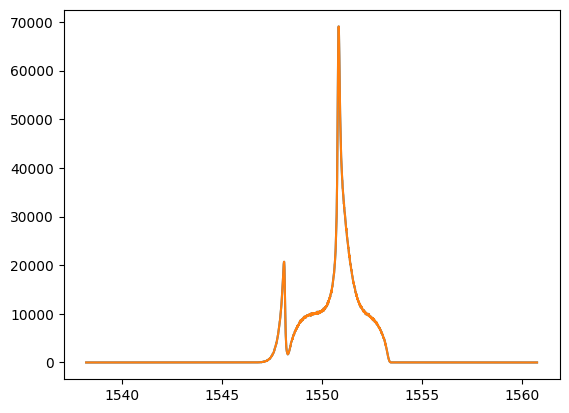

In [17]:
N=300000
vout = 500
lam, flux = K_H_from_Combine_data('all', atom_num, index, vout, vemit, vran)[:2]
print(len(lam))
xx_lam = np.linspace(lam.min(),lam.max(),N)
yy_interpol = interp1d(lam, flux, bounds_error=False, fill_value=0)
yy_lam = yy_interpol(xx_lam)
plt.plot(lam,flux)
plt.plot(xx_lam,yy_lam)
# emis = emis_interp(r)

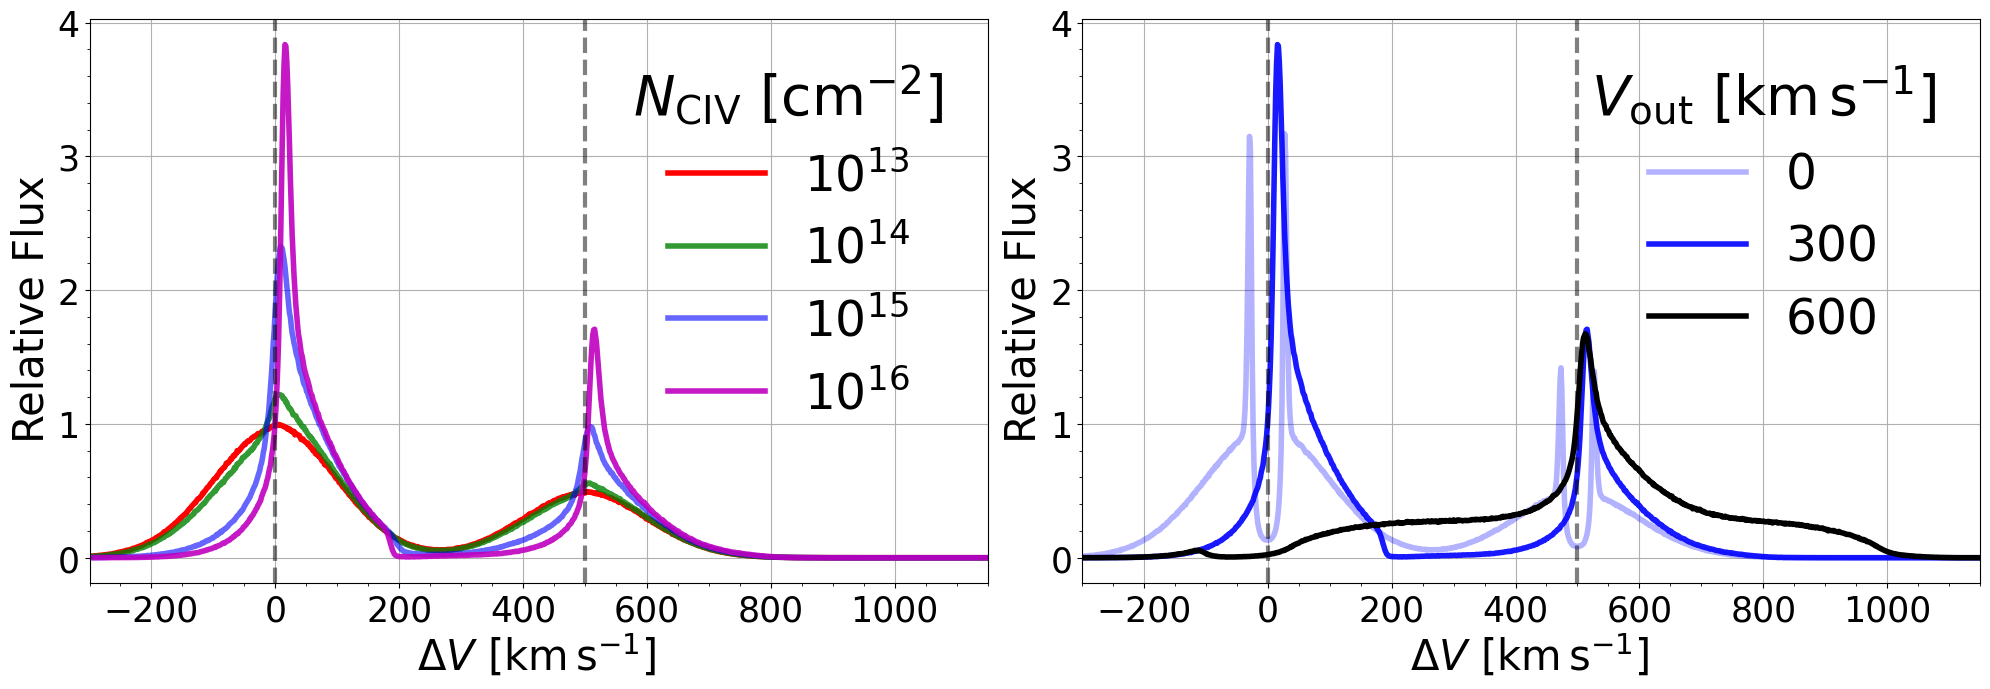

In [18]:
fig = plt.figure(1,figsize=(20,7))


plt.subplot(121)
atom_num,  vout,vemit,vran = 10 , 300, 100,11.8
index = 13

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'r-',lw=4,alpha=1.0,label=f'$10^{{{index}}}$')

index = 14
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'g-',lw=4,alpha=0.8,label=f'$10^{{{index}}}$')

index = 15
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.6,label=f'$10^{{{index}}}$')

index = 16
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'m-',lw=4,alpha=0.9,label=f'$10^{{{index}}}$')

plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


plt.xlim(-300,1150)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks([0.0,1.0,2.0,3.0,4.0],fontsize=25)
plt.ylabel(r'Relative Flux ',fontsize=30)
plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()

plt.subplot(122)
atom_num,  vout,vemit,vran = 10 , 000, 100,11.8
index = 16

# normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.3,label=f'{vout}')

vout = 300
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=4,alpha=0.9,label=f'{vout}')

vout = 600
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=4,alpha=1,label=f'{vout}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


plt.xlim(-300,1150)
# plt.ylim(ymax=1.25)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks([0,1.0,2.0,3.0,4.0],fontsize=25)
plt.ylabel(r'Relative Flux ',fontsize=30)
plt.legend(title=r'$V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,1.75,s=r'V$_{\rm out} = 600~[\rm km\, s^{-1}]$',size=20)

# plt.subplot(133)

# rr = np.arange(12, 17, 1)
# atom = [13,20,32,50,79]
# rr_reshaped = rr.reshape(-1, 1)
# total_N_c = 10**rr_reshaped * atom / 10
# total_N_c = total_N_c.flatten()
# vemit,vran =100,11.8
# V = np.arange(0,1200,200)
# for jj, vout in enumerate(V):
#     ratio = np.zeros(len(total_N_c))
#     for ii, N_civ in enumerate(total_N_c):
#         index = math.floor(math.log10(N_civ))
#         atom_n = int(N_civ/ 10**index*10)
#         ratio[ii] = doublet_ratio('all',atom_n,index,vout,vemit,vran)
#     plt.plot(total_N_c,ratio,'-o',label=f'{vout}')
#     plt.xscale('log')
        

# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


# # plt.axhline(y=0.25, xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

# plt.legend(fontsize=25, title=r'$V_{\rm out} ~ [\rm km\, s^{-1}]$',title_fontsize=30,ncol=2,frameon=False)

# plt.xticks(fontsize=25)
# plt.xlabel(r'$ N_{\rm CIV} ~[\rm cm^{-2}]$ ',fontsize=30)
# plt.xlim(2e12,5e16)

# plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=25)
# plt.ylim(-0.1,2.4)
# plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
# plt.minorticks_on()
# plt.grid(True)



plt.tight_layout()


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_300_600_velocity.pdf', bbox_inches='tight')


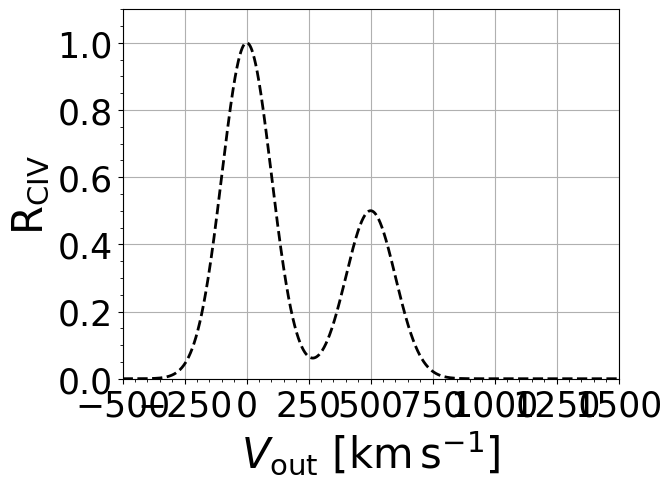

In [19]:
xx = np.arange(-500,1500,0.5)

aa = ((xx-0) / (100*np.sqrt(2)) )**2
bb = ((xx-500) / (100*np.sqrt(2)) )**2
yy = np.exp(-aa) + 0.5*np.exp(-bb)
plt.plot(xx,yy,'--',color='k',lw=2)
plt.xlim(-500,1500)
plt.ylim(0,1.1)
plt.xlabel(r'$V_{\rm out} ~ [\rm km\, s^{-1}]$',fontsize=30)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.minorticks_on()
plt.grid(True)

In [20]:
print(np.log10(3.2e13))

13.505149978319906


In [21]:
# import os
# import shutil


# v_rand = 50
# os.makedirs('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Ran_{}'.format(v_rand), exist_ok=True)

# rr = np.array([14,15,16])
# atom = np.array([10])
# vv = np.array([0,100,200,300,400,500])
# v_emit = np.array([100,200,300])


# def mv_data(Line , atom_num , atom_index, vout, vemit, vran):
#     out, out_order = calculate_order_and_value(vout)
#     emit, emit_order = calculate_order_and_value(vemit)
#     ran , ran_order = calculate_order_and_value(vran)

#     path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    
#     target_path = r'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Ran_{}/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(vran,atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
#     return shutil.copy2(path, target_path)



# for ii, atom_index in enumerate(rr):
#     for jj, atom_num in enumerate(atom):
#         for kk, vout in enumerate(vv):
#             for mm, vemit in enumerate(v_emit):
#                 a =mv_data('all' , atom_num , atom_index, vout, vemit, v_rand)





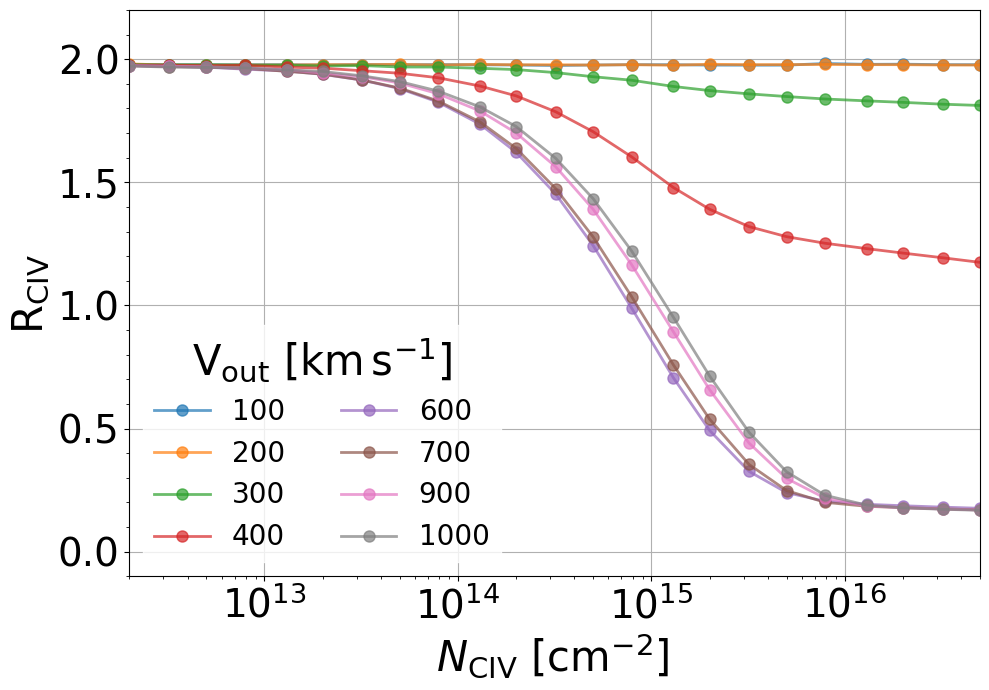

In [22]:
import math
fig = plt.figure(1,figsize=(10,7))

# plt.subplot(121)

rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vemit,vran =100,11.8

V = np.arange(0,1200,200)
V = np.array([100,200,300,400,600,700,900,1000])
for jj, vout in enumerate(V):
    ratio = np.zeros(len(total_N_c))
    for ii, N_civ in enumerate(total_N_c):
        index = math.floor(math.log10(N_civ))
        atom_n = int(N_civ/ 10**index*10)
        ratio[ii] = doublet_ratio('all',atom_n,index,vout,vemit,vran)
    plt.plot(total_N_c,ratio,'-o',alpha=0.7,lw=2,markersize=8,label=f'{vout}')
    plt.xscale('log')
        

# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.2,lw=5)
# plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)

# plt.axhline(y=0.25, xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)


leg = plt.legend(
    fontsize=20, 
    title=r'$ \rm V_{\rm out} ~ [\rm km\, s^{-1}]$',
    title_fontsize=30,
    ncol=2,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.8)
leg.get_frame().set_edgecolor('white')




plt.xticks(fontsize=28)
plt.xlabel(r'$ N_{\rm CIV} ~[\rm cm^{-2}]$ ',fontsize=30)
plt.xlim(2e12,5e16)

plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=28)
plt.ylim(-0.1,2.2)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()


# plt.subplot(122)

# rr = np.arange(12, 17, 1)
# atom = [13,20,32,50,79]
# rr_reshaped = rr.reshape(-1, 1)
# total_N_c = 10**rr_reshaped * atom / 10
# total_N_c = total_N_c.flatten()


# vemit,vran =100,11.8


# V = np.arange(0,1100,100)



# vemit = 100
# for jj, index in enumerate(rr):
#     ratio = np.zeros(len(V))
#     for ii,vout in enumerate(V):
#         ratio[ii] = doublet_ratio('all',13,index,vout,vemit,vran)
#     plt.plot(V,ratio,'o',linestyle='-',lw=3,label=f'{index}')

        
# # plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


# plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=2,alpha=0.5)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=2,alpha=0.5)

# plt.legend(loc='lower left',fontsize=20, title=r'$\log{N_{\rm CIV}} ~ [\rm cm^{-2}]$',title_fontsize=30,ncol=2,frameon=False)

# plt.xticks(fontsize=25)
# plt.xlabel(r'$ V_{\rm out} ~[\rm km \, s^{-1}]$ ',fontsize=30)
# plt.xlim(-5,1005)

# plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=25)
# plt.ylim(-0.1,2.2)
# plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)


# plt.minorticks_on()
# plt.grid(True)
# plt.tight_layout()


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_doublet_RT.pdf',bbox_inches='tight')

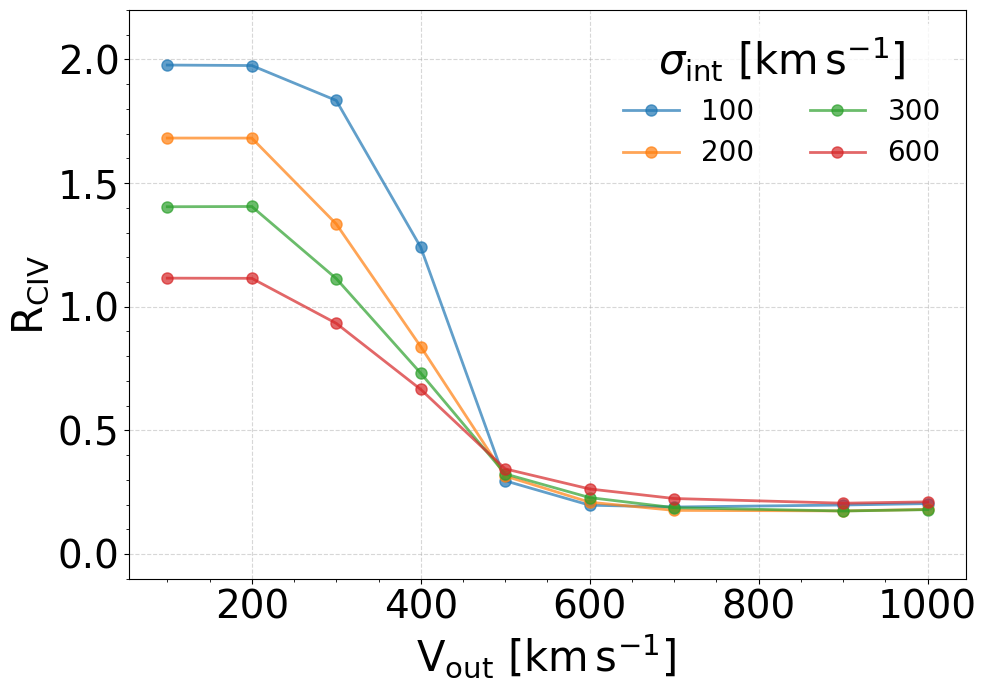

In [23]:
import math
fig = plt.figure(1,figsize=(10,7))

# plt.subplot(121)

rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vran = 11.8

V = np.array([100,200,300,400,500,600,700,900,1000])
vemit = np.array([100,200,300,600])

atom_n = 10
index = 16
for jj, emit in enumerate(vemit):
    ratio = np.zeros(len(V ))
    for ii, vout in enumerate(V):
        ratio[ii] = doublet_ratio('all',atom_n,index,vout,emit,vran)
    plt.plot(V,ratio,'-o',alpha=0.7,lw=2,markersize=8,label=f'{emit}')
    # plt.xscale('log')
        
# plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)


# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.2,lw=5)
# plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)

# plt.axhline(y=0.25, xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)


leg = plt.legend(
    fontsize=20, 
    title=r'$ \sigma_{\rm int} ~ [\rm km\, s^{-1}]$',
    title_fontsize=30,
    ncol=2,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.8)
leg.get_frame().set_edgecolor('white')




plt.xticks(fontsize=28)
plt.xlabel(r'$\rm V_{\rm out} ~[\rm km\,s^{-1}]$ ',fontsize=30)
# plt.xlim(2e12,5e16)

plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=28)
plt.ylim(-0.1,2.2)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Intrinsic_width_doublet_vout.pdf',bbox_inches='tight')

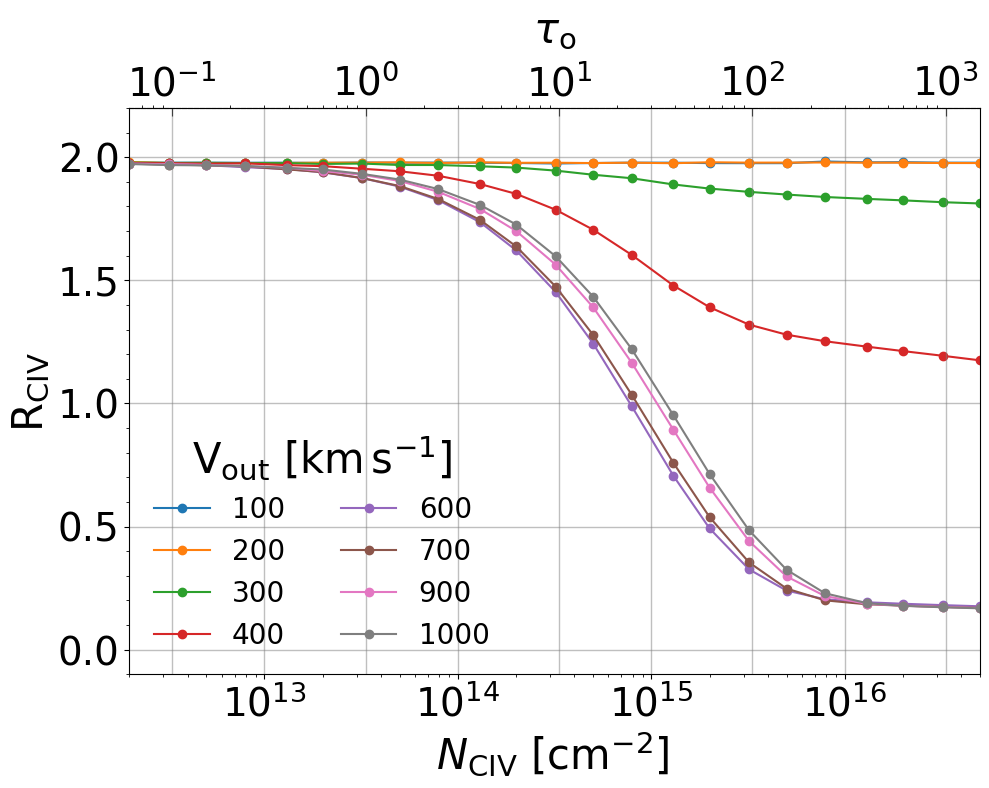

In [24]:
from matplotlib.ticker import LogLocator, FuncFormatter

# 기존 코드로 Figure 생성
fig, ax1 = plt.subplots(figsize=(10, 7)) 


rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vemit,vran =100,11.8




V = np.arange(0,1200,200)
V = np.array([100,200,300,400,600,700,900,1000])
for jj, vout in enumerate(V):
    ratio = np.zeros(len(total_N_c))
    for ii, N_civ in enumerate(total_N_c):
        index = math.floor(math.log10(N_civ))
        atom_n = int(N_civ/ 10**index*10)
        ratio[ii] = doublet_ratio('all',atom_n,index,vout,vemit,vran)
    plt.plot(total_N_c,ratio,'-o',label=f'{vout}')
    plt.xscale('log')
        

# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.2,lw=5)
# ax1.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)
# ax1.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)

# plt.axhline(y=0.2, xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)

ax1.legend(fontsize=20, title=r'$ \rm V_{\rm out} ~ [\rm km\, s^{-1}]$',title_fontsize=30,ncol=2,frameon=False)

ax1.tick_params(axis='x', labelsize=28)
ax1.set_xlabel(r'$ N_{\rm CIV} ~[\rm cm^{-2}]$ ',fontsize=30)
ax1.set_xlim(2e12,5e16)

ax1.set_yticks([0., 0.5, 1.0, 1.5, 2.0])
ax1.tick_params(axis='y', labelsize=28)
ax1.set_ylim(-0.1,2.2)
ax1.set_ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
ax1.minorticks_on()
ax1.grid(True,linestyle='-',color='grey',alpha=0.5,lw=1)
plt.tight_layout()

tao_K = np.zeros(len(total_N_c))
for ii, N_civ in enumerate(total_N_c):
    index = math.floor(math.log10(N_civ))
    atom_n = int(N_civ/ 10**index*10)
    tao_K[ii] = tau_0('k',atom_n,index,vout,vemit,vran)

def Nc_to_tauK(x):
    return np.interp(x, total_N_c, tao_K)

def tauK_to_Nc(x):
    return np.interp(x, tao_K, total_N_c)

secax = ax1.secondary_xaxis('top', functions=(Nc_to_tauK, tauK_to_Nc))
# secax.set_xlabel(r'$\overline{\tau_{\rm 0,K}}$', fontsize=28)
secax.tick_params(axis='x', labelsize=28)
secax.set_xlabel(r'${\tau_{\rm o}}$', fontsize=30, labelpad=15)
secax.tick_params(axis='x', which='major', direction='in', length=6)
secax.spines['top'].set_linestyle('--')
# 먼저 보간용 함수 정의 (tau_K → total_N_c)

import numpy as np
def tauK_to_Nc(tau_val):
    return np.interp(tau_val, tao_K, total_N_c)

# 예: tau_K = 1, 10에서 수직선 추가
for t in [0.1,1, 10,100,1000]:
    Nc_val = tauK_to_Nc(t)
    ax1.axvline(x=Nc_val, linestyle='-',color='grey',alpha=0.5,lw=1)


# plt.savefig('/home/jin/바탕화면/Gaussian_doublet_RT.pdf',bbox_inches='tight')
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_doublet_RT.pdf',bbox_inches='tight')


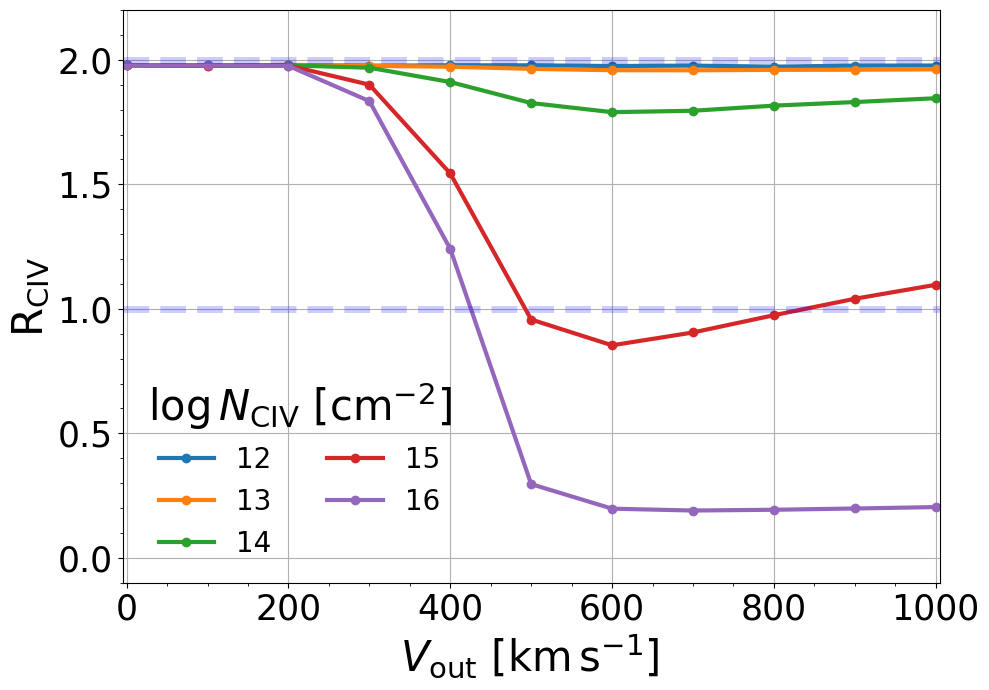

In [25]:
fig = plt.figure(1,figsize=(10,7))
rr = np.arange(12, 17, 1)
atom = [10,13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vemit,vran =100,11.8


V = np.arange(0,1100,100)



vemit = 100
# for jj, index in enumerate(rr):
#     for kk, atom_n in enumerate(atom):
#         ratio = np.zeros(len(V))
#         for ii,vout in enumerate(V):
#             ratio[ii] = doublet_ratio('all',atom_n,index,vout,vemit,vran)
#         plt.plot(V,ratio,'o',linestyle='-',lw=3,label=f'{index}')

for jj, index in enumerate(rr):
    ratio = np.zeros(len(V))
    for ii,vout in enumerate(V):
        ratio[ii] = doublet_ratio('all',10,index,vout,vemit,vran)
    plt.plot(V,ratio,'o',linestyle='-',lw=3,label=f'{index}')
        
# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)
plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)

plt.legend(loc='lower left',fontsize=20, title=r'$\log{N_{\rm CIV}} ~ [\rm cm^{-2}]$',title_fontsize=30,ncol=2,frameon=False)

plt.xticks(fontsize=25)
plt.xlabel(r'$ V_{\rm out} ~[\rm km \, s^{-1}]$ ',fontsize=30)
plt.xlim(-5,1005)

plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=25)
plt.ylim(-0.1,2.2)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)


plt.minorticks_on()
plt.grid(True)
plt.tight_layout()


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_doublet_Vout.pdf',bbox_inches='tight')

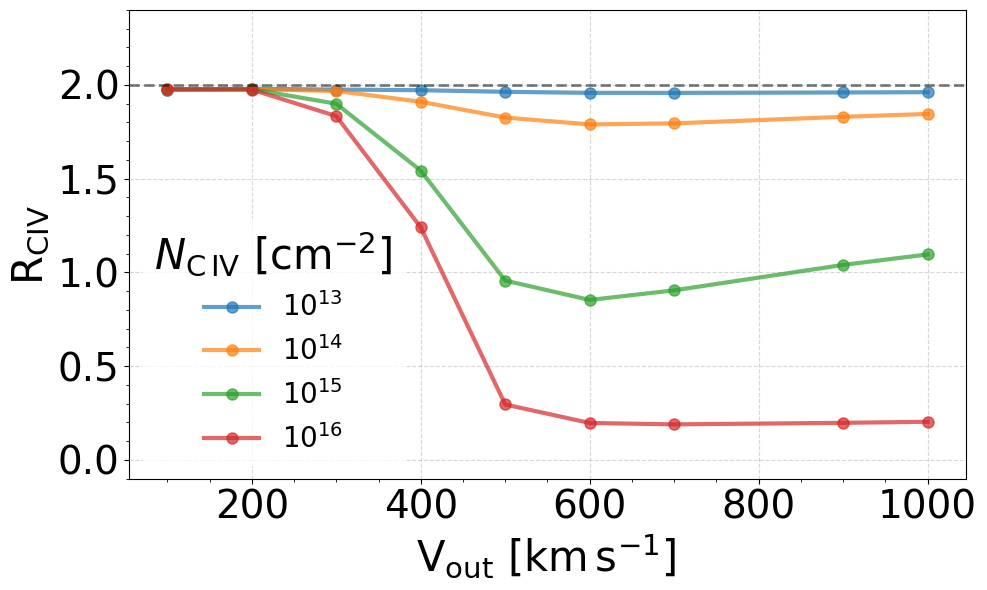

In [26]:
import math
fig = plt.figure(1,figsize=(10,6))

# plt.subplot(121)

rr = np.arange(13, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vran =11.8

V = np.array([100,200,300,400,500,600,700,900,1000])
vemit = np.array([100])

atom_n = 10
index = 16
for jj, order in enumerate(rr):
    ratio = np.zeros(len(V ))
    for ii, vout in enumerate(V):
        ratio[ii] = doublet_ratio('all',10,order,vout,vemit[0],vran)
    plt.plot(V,ratio,'-o',alpha=0.7,lw=3,markersize=8,label=f'$10^{{{order}}}$')
    # plt.xscale('log')
plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='k',lw=2,alpha=0.5)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.5)


# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.2,lw=5)
# plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)
# plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)

# plt.axhline(y=0.25, xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5)


leg = plt.legend(
    fontsize=20, 
    title=r'$ N_{\rm C \, IV} ~ [\rm cm^{-2}]$',
    title_fontsize=30,
    ncol=1,
    frameon=True)  # ← True로!
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.8)
leg.get_frame().set_edgecolor('white')




plt.xticks(fontsize=28)
plt.xlabel(r'$\rm V_{\rm out} ~[\rm km\,s^{-1}]$ ',fontsize=30)
# plt.xlim(2e12,5e16)

plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=28)
plt.ylim(-0.1,2.4)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Gaussian_doublet_Vout')

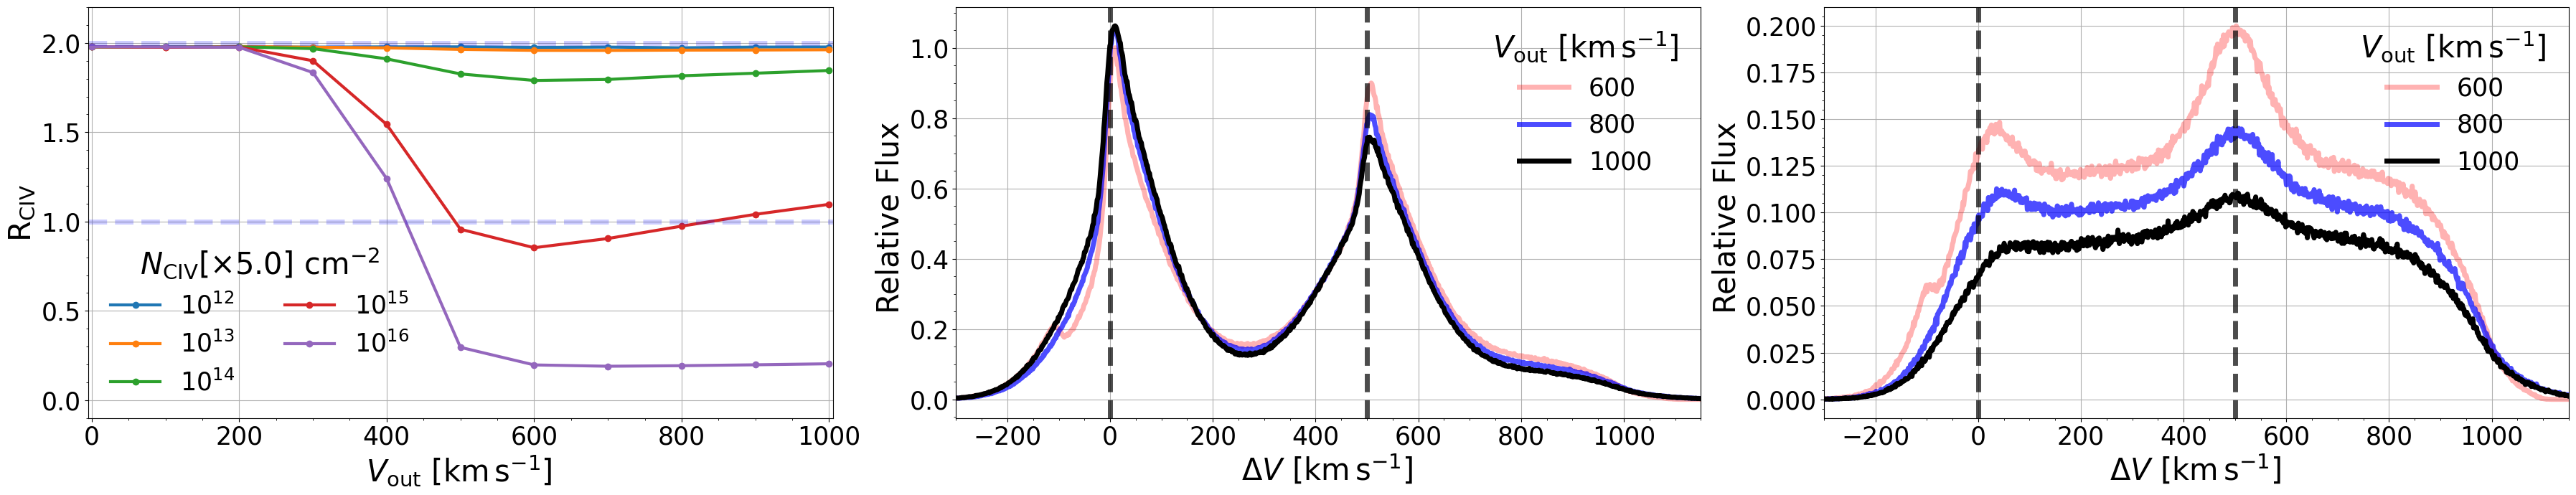

In [27]:
fig = plt.figure(1,figsize=(36,7))


plt.subplot(131)
rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vemit,vran =100,11.8


V = np.arange(0,1100,100)



vemit = 100
for jj, index in enumerate(rr):
    ratio = np.zeros(len(V))
    for ii,vout in enumerate(V):
        ratio[ii] = doublet_ratio('all',10,index,vout,vemit,vran)
    plt.plot(V,ratio,'o',linestyle='-',lw=3,label=f'$10^{{{index}}}$')

        
# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)
plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='b',lw=5,alpha=0.2)

plt.legend(loc='lower left',fontsize=25, title=r'$N_{\rm CIV} [\times 5.0] ~ \rm cm^{-2}$',title_fontsize=30,ncol=2,frameon=False)

plt.xticks(fontsize=25)
plt.xlabel(r'$ V_{\rm out} ~[\rm km \, s^{-1}]$ ',fontsize=30)
plt.xlim(-5,1005)

plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=25)
plt.ylim(-0.1,2.2)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)


plt.minorticks_on()
plt.grid(True)
plt.tight_layout()


atom_num,  vout,vemit,vran = 10 , 600, 100,11.8
index = 15

plt.subplot(132)


normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

vout = 600
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[1]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')


vout = 800
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=5,alpha=0.7,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=5,alpha=0.7,label=f'{vout}')


vout = 1000
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=5,alpha=1,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=5,alpha=1,label=f'{vout}')



# vout = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=2,alpha=1,label=f'{vout}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)


plt.xlim(-300,1150)
# plt.xlim(-300,200)
# plt.ylim(ymax=1.25)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks(fontsize=25)
plt.ylabel(r'Relative Flux ',fontsize=30)
plt.legend(loc='upper right',title=r'$V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=30,fontsize=25,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,1.75,s=r'V$_{\rm out} = 600~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()



plt.subplot(133)

# vout = 100
# normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2].max()
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'k-',lw=5,alpha=1,label=f'{vout}')


vout = 600
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[2]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')


vout = 800
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'b-',lw=5,alpha=0.7,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[2]/normal,'k-',lw=5,alpha=0.7,label=f'{vout}')


vout = 1000
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'k-',lw=5,alpha=1,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[2]/normal,'b-',lw=5,alpha=1,label=f'{vout}')


# vout = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=2,alpha=1,label=f'{vout}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)


plt.xlim(-300,1150)
# plt.ylim(ymax=1.25)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks(fontsize=25)
plt.ylabel(r'Relative Flux ',fontsize=30)
plt.legend(loc='upper right',title=r'$V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=30,fontsize=25,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,1.75,s=r'V$_{\rm out} = 600~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RCIV_total_Halo.pdf')

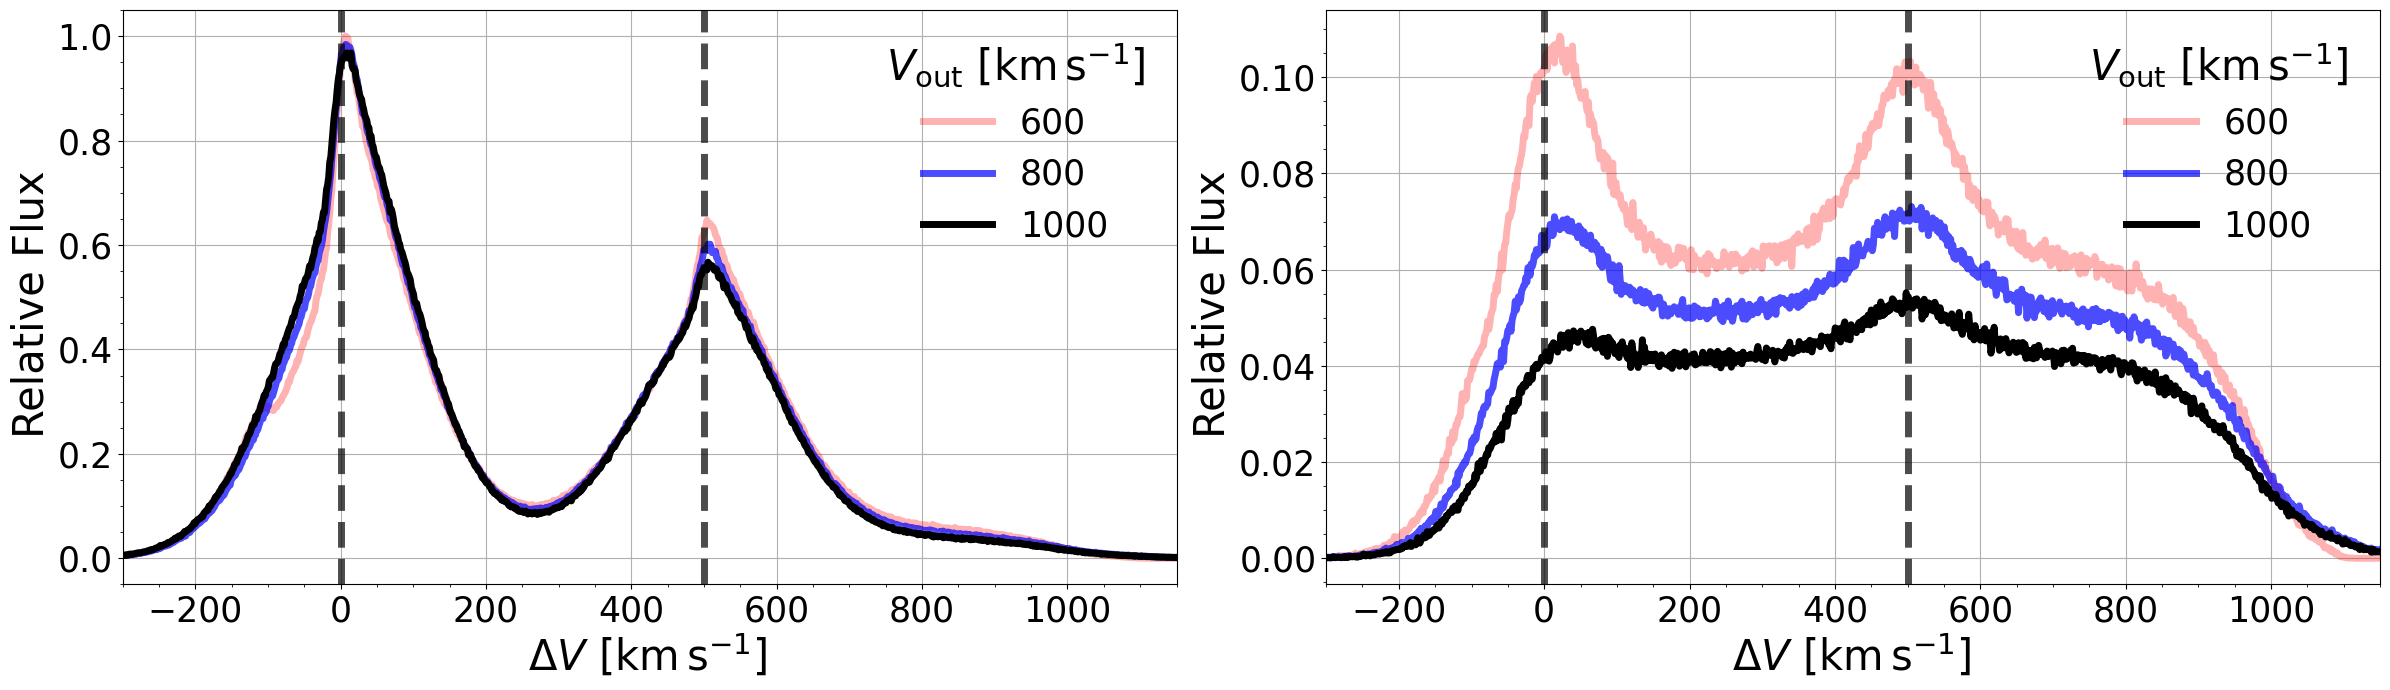

In [28]:
fig = plt.figure(1,figsize=(24,7))



atom_num,  vout,vemit,vran = 50 , 600, 100,11.8
index = 14

plt.subplot(121)


normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()

vout = 600
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[1]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')


vout = 800
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=5,alpha=0.7,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=5,alpha=0.7,label=f'{vout}')


vout = 1000
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=5,alpha=1,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[1]/normal,'b-',lw=5,alpha=1,label=f'{vout}')



# vout = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=2,alpha=1,label=f'{vout}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)


plt.xlim(-300,1150)
# plt.xlim(-300,200)
# plt.ylim(ymax=1.25)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks(fontsize=25)
plt.ylabel(r'Relative Flux ',fontsize=30)
plt.legend(loc='upper right',title=r'$V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=30,fontsize=25,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,1.75,s=r'V$_{\rm out} = 600~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()



plt.subplot(122)

# vout = 100
# normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2].max()
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'k-',lw=5,alpha=1,label=f'{vout}')


vout = 600
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[2]/normal,'r-',lw=5,alpha=0.3,label=f'{vout}')


vout = 800
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'b-',lw=5,alpha=0.7,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[2]/normal,'k-',lw=5,alpha=0.7,label=f'{vout}')


vout = 1000
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[2]/normal,'k-',lw=5,alpha=1,label=f'{vout}')
# plt.plot(lam_to_vel(K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('H',atom_num,index, vout,vemit,vran)[2]/normal,'b-',lw=5,alpha=1,label=f'{vout}')


# vout = 600
# plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,linestyle='-',color='k',lw=2,alpha=1,label=f'{vout}')



plt.axvline(0,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)
plt.axvline(500,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.7,lw=5)


plt.xlim(-300,1150)
# plt.ylim(ymax=1.25)
plt.xticks(fontsize=25)
plt.xlabel(r'$\Delta V ~[\rm km \, s^{-1}]$ ',fontsize=30)

# plt.xlim(-300,1050)
plt.yticks(fontsize=25)
plt.ylabel(r'Relative Flux ',fontsize=30)
plt.legend(loc='upper right',title=r'$V_{\rm out}~[\rm km \, s^{-1}]$',title_fontsize=30,fontsize=25,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,1.75,s=r'V$_{\rm out} = 600~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Spectrum_Total_Halo.pdf')

In [29]:
# atom , index , vout, vemit, vrand= 32, 15 , 600 , 100 , 30
# lam_K, spec_tot_K , spec_halo_K = K_H_from_Combine_data('K',atom, index, vout, vemit, vrand) 
# lam_H, spec_tot_H , spec_halo_H = K_H_from_Combine_data('H',atom, index, vout, vemit, vrand) 
# doublet_ratio_R = doublet_ratio('H',atom, index, vout, vemit, vrand)
# print(doublet_ratio_R)
# plt.plot(lam_to_vel(lam_K), spec_tot_K,'r-')
# plt.plot(lam_to_vel(lam_H), spec_tot_H,'b-')

# atom , index , vout, vemit, vrand= 32, 15 , 800 , 100 , 30
# lam_K, spec_tot_K , spec_halo_K = K_H_from_Combine_data('K',atom, index, vout, vemit, vrand) 
# lam_H, spec_tot_H , spec_halo_H = K_H_from_Combine_data('H',atom, index, vout, vemit, vrand) 
# doublet_ratio_R = doublet_ratio('H',atom, index, vout, vemit, vrand)
# print(doublet_ratio_R)
# plt.plot(lam_to_vel(lam_K), spec_tot_K,'k--')
# plt.plot(lam_to_vel(lam_H), spec_tot_H,'k--')


# atom , index , vout, vemit, vrand= 32, 15 , 1000 , 100 , 30
# lam_K, spec_tot_K , spec_halo_K = K_H_from_Combine_data('K',atom, index, vout, vemit, vrand) 
# lam_H, spec_tot_H , spec_halo_H = K_H_from_Combine_data('H',atom, index, vout, vemit, vrand) 
# doublet_ratio_R = doublet_ratio('H',atom, index, vout, vemit, vrand)
# print(doublet_ratio_R)
# plt.plot(lam_to_vel(lam_K), spec_tot_K,'r--')
# plt.plot(lam_to_vel(lam_H), spec_tot_H,'b--')


# plt.xlim(-250,1000)
 


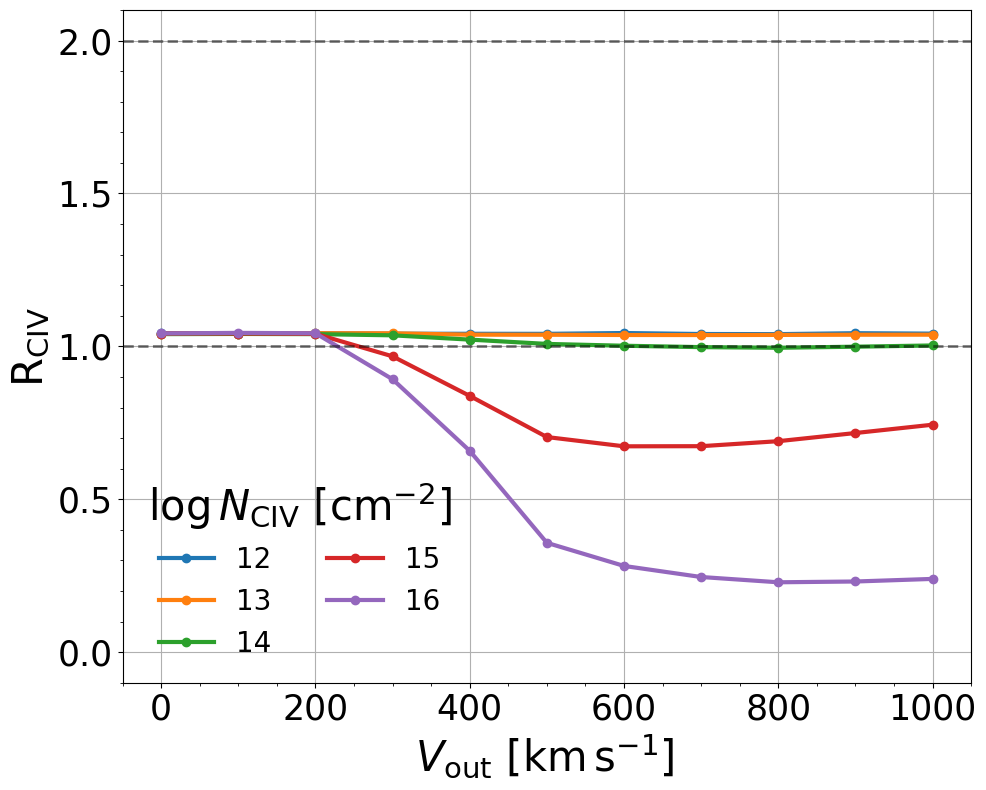

In [30]:
import math
fig = plt.figure(1,figsize=(10,8))

rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


vemit,vran =200,11.8


V = np.arange(0,1100,100)



vemit = 1000
for jj, index in enumerate(rr):
    ratio = np.zeros(len(V))
    for ii,vout in enumerate(V):
        ratio[ii] = doublet_ratio('all',10,index,vout,vemit,vran)
    plt.plot(V,ratio,'-o',lw=3,label=f'{index}')

        
# plt.axvline(x=2.66985426e+13, ymin=0,ymax=1,linestyle='--',color='k',alpha=0.5,lw=3)


plt.axhline(y=2, xmin=0,xmax=1,linestyle='--',color='k',lw=2,alpha=0.5)
plt.axhline(y=1, xmin=0,xmax=1,linestyle='--',color='k',lw=2,alpha=0.5)

plt.legend(loc='lower left',fontsize=20, title=r'$\log{N_{\rm CIV}} ~ [\rm cm^{-2}]$',title_fontsize=30,ncol=2,frameon=False)

plt.xticks(fontsize=25)
plt.xlabel(r'$ V_{\rm out} ~[\rm km \, s^{-1}]$ ',fontsize=30)
# plt.xlim(2e12,5e16)

plt.yticks([0.,0.5,1.0,1.5,2.0],fontsize=25)
plt.ylim(-0.1,2.1)
plt.ylabel(r'$\rm R_{\rm CIV}$ ',fontsize=30)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/vout_emit.png')

(-1500.0, 1500.0)

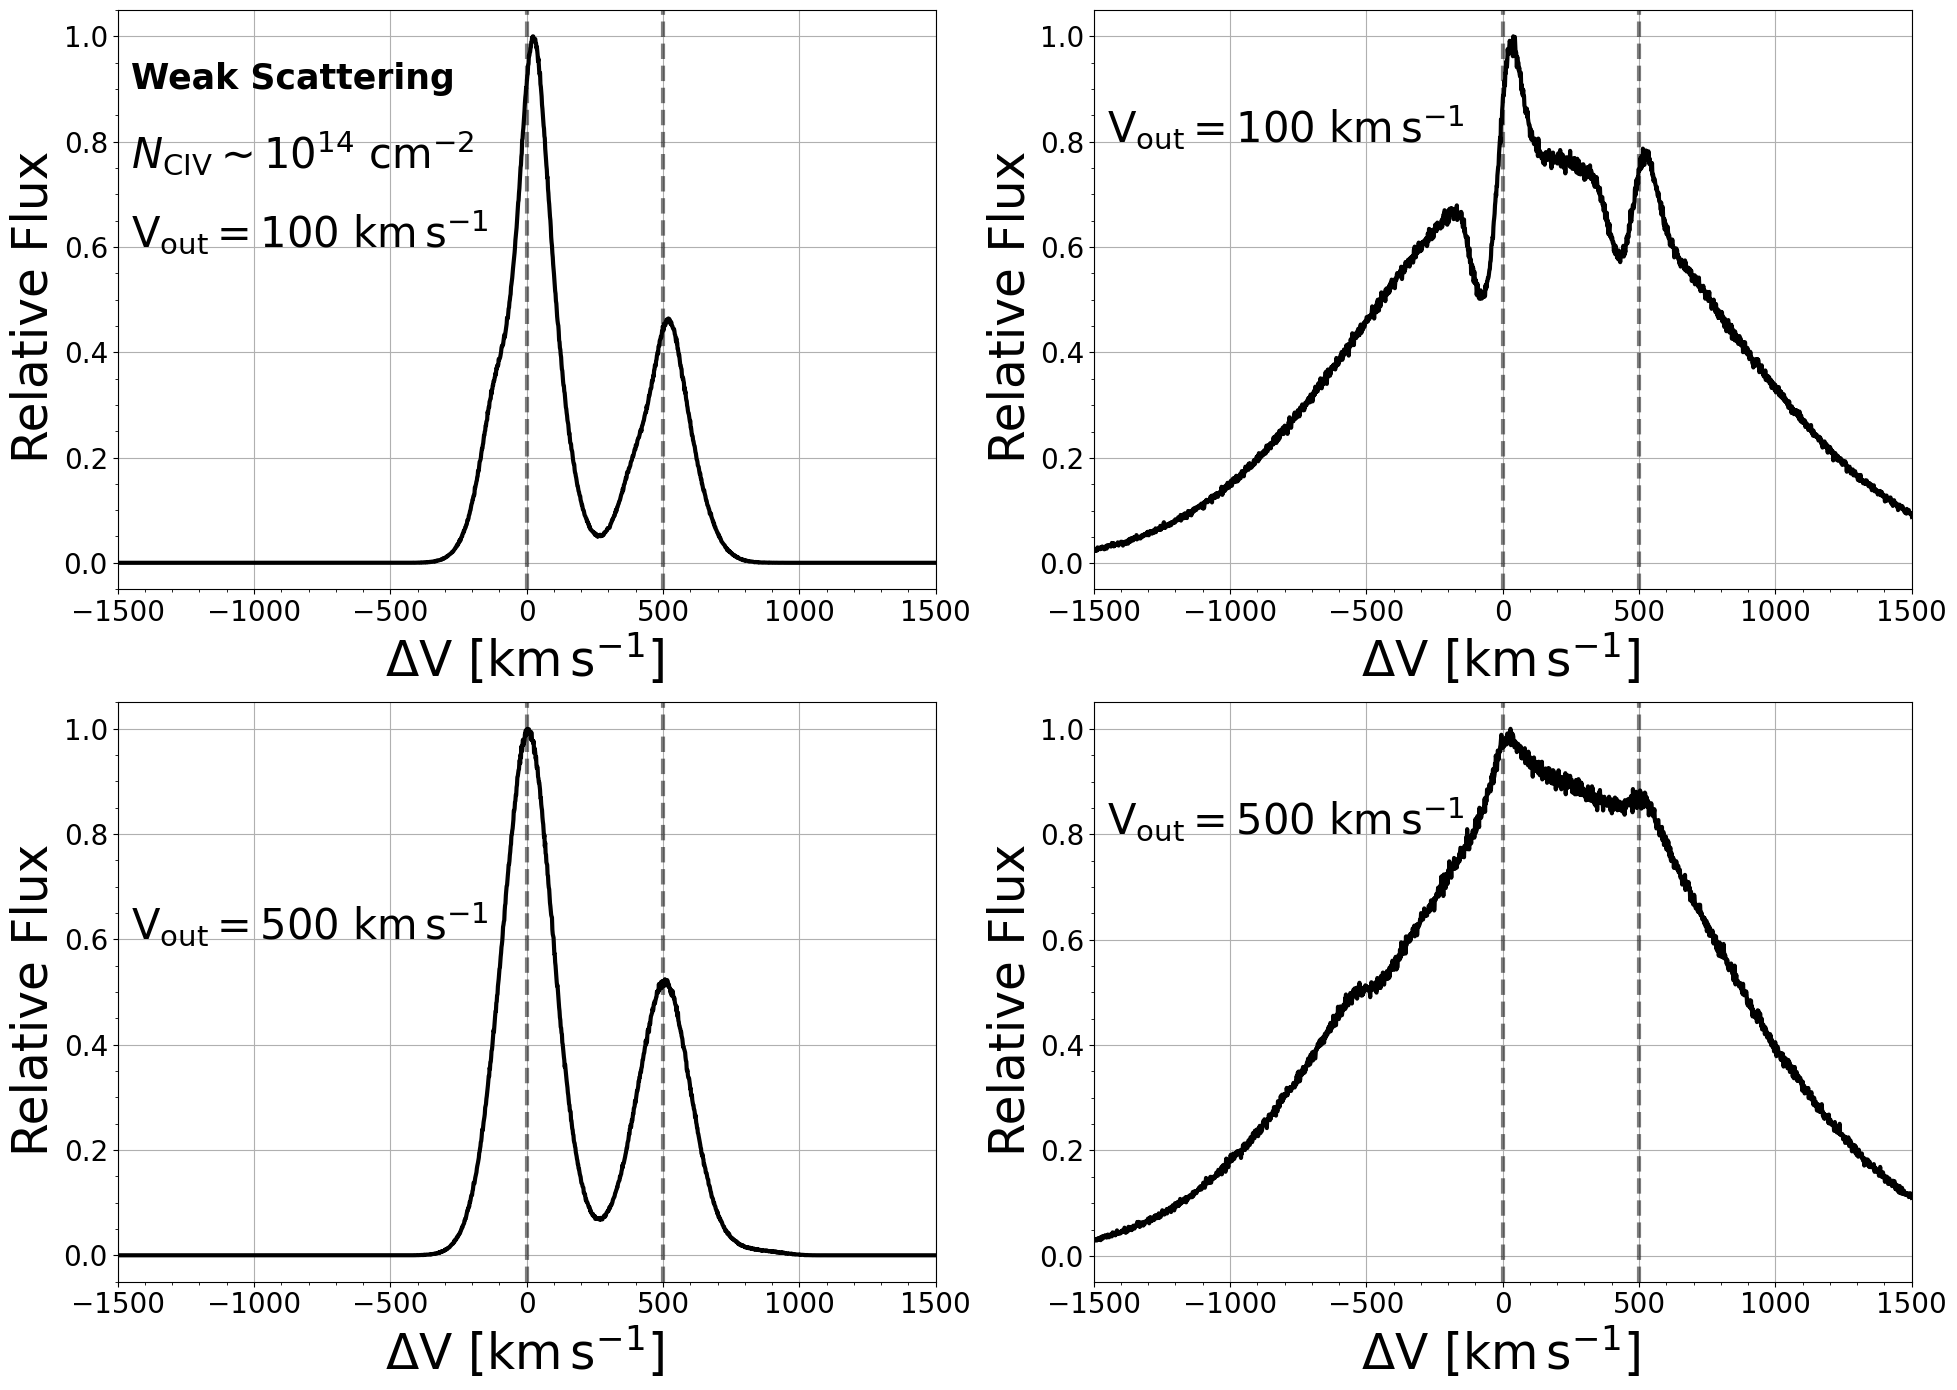

In [31]:
fig = plt.figure(1,figsize=(25,14))
index = 14
atom_num,vran = 10, 50

plt.subplot(221)
vout,vemit =  100, 100



normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')

plt.text(-1450,0.9,s='Weak Scattering',fontweight='bold',size=25)
plt.text(-1450,0.75,s=f'$N_{{\\rm CIV}} \\sim 10^{{{index}}}~{{\\rm cm^{{-2}}}}$',fontweight='bold',size=30)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)

plt.tight_layout()
plt.xlim(-1500,1500)

plt.subplot(222)
vout,vemit =  100, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.8,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)


plt.subplot(223)
vout,vemit =  500, 100

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)



plt.subplot(224)
vout,vemit =  500, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.8,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.xlim(-1500,1500)


# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_Mock_ws.pdf',bbox_inches="tight") 


(-1500.0, 1500.0)

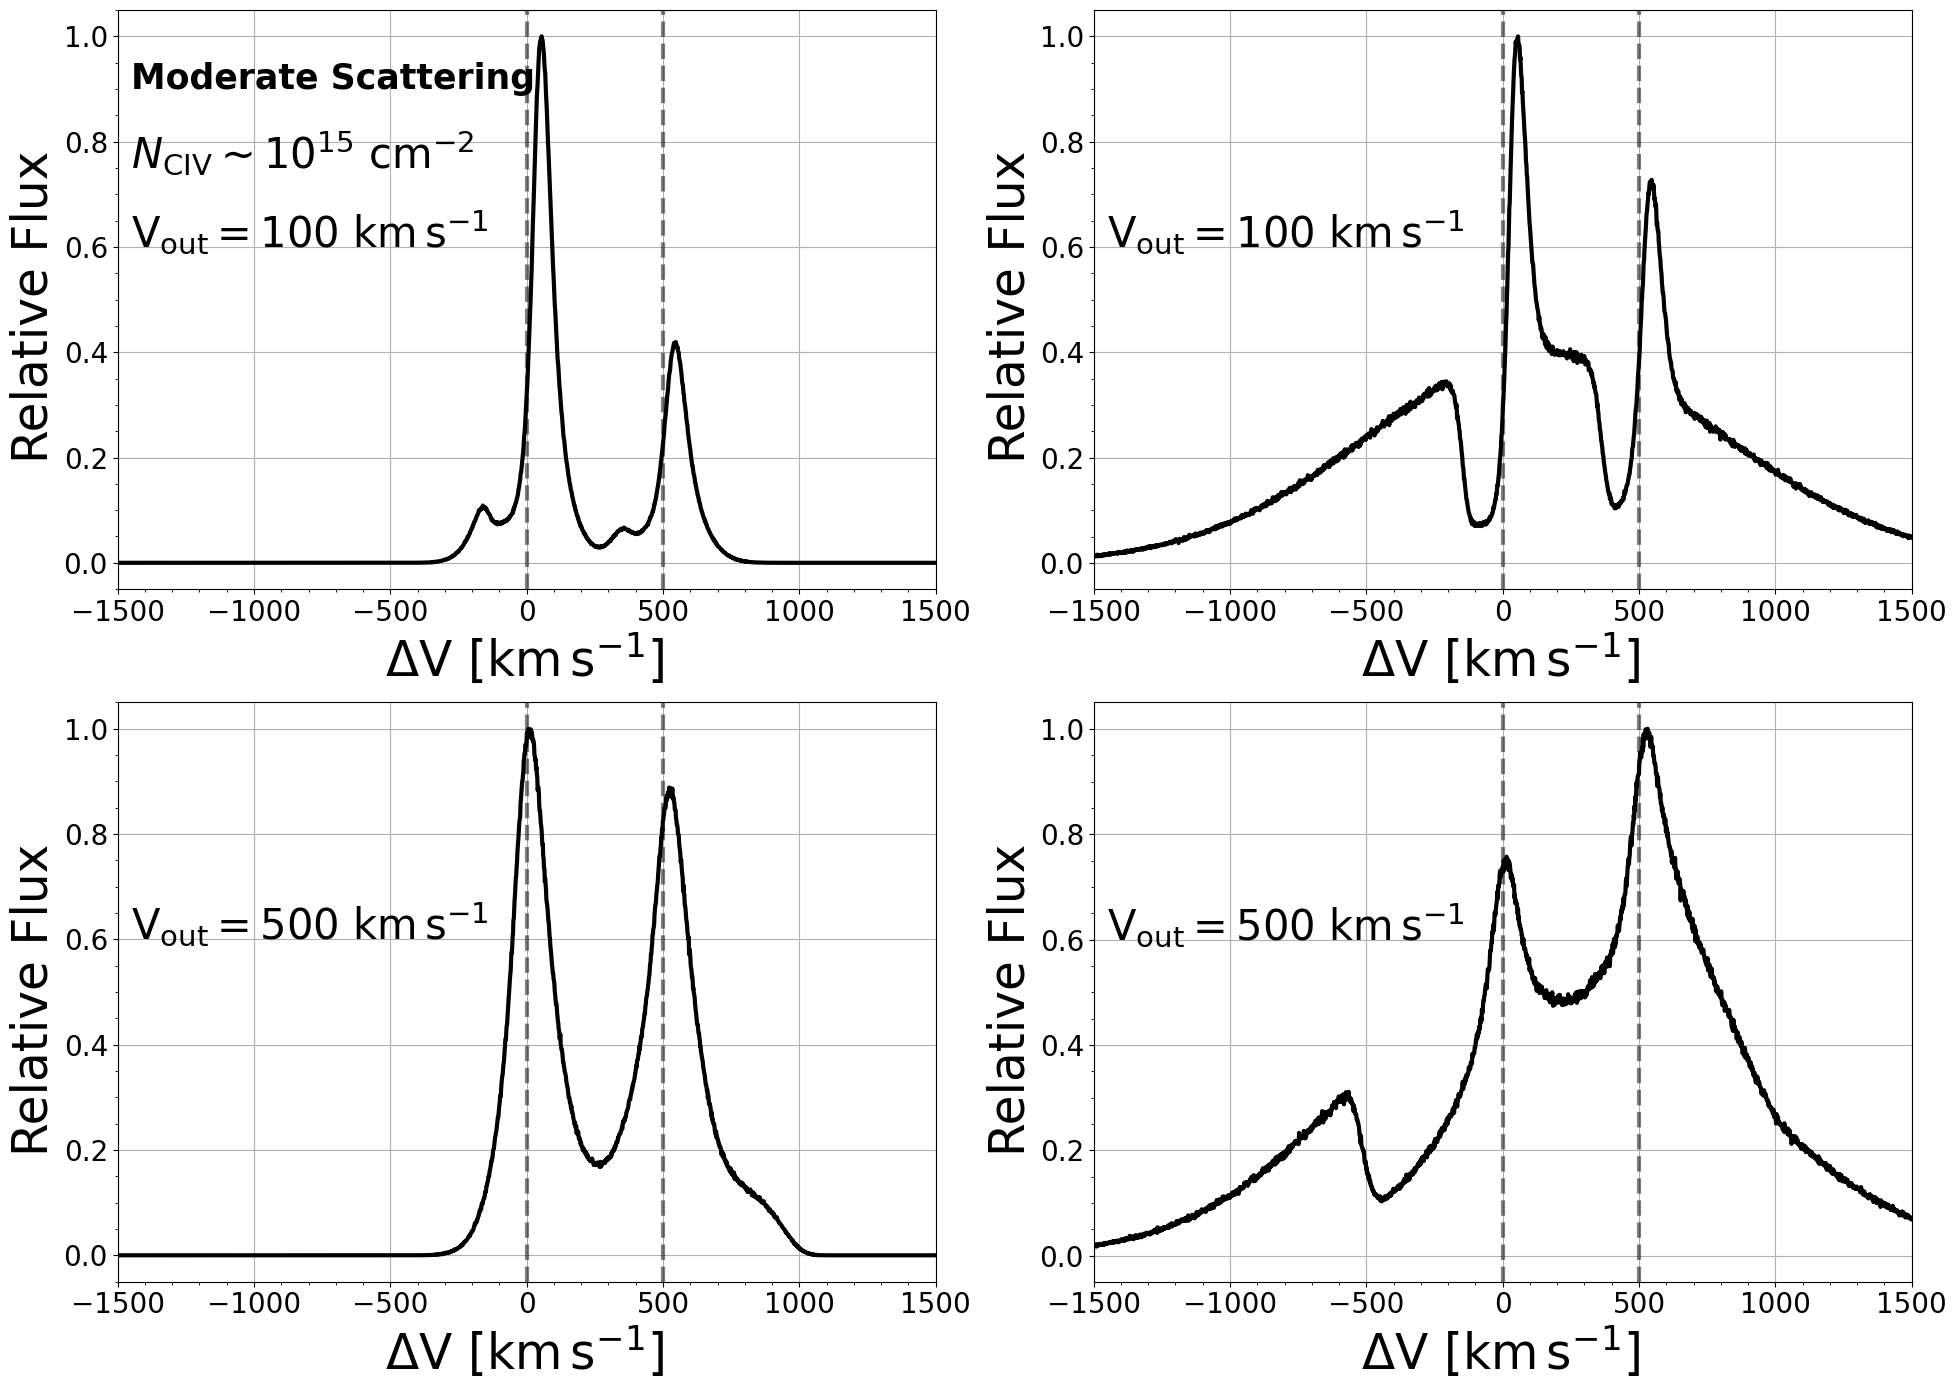

In [32]:
fig = plt.figure(1,figsize=(25,14))
index = 15
atom_num,vran = 10, 50

plt.subplot(221)
vout,vemit =  100, 100



normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')

plt.text(-1450,0.9,s='Moderate Scattering',fontweight='bold',size=25)
plt.text(-1450,0.75,s=f'$N_{{\\rm CIV}} \\sim 10^{{{index}}}~{{\\rm cm^{{-2}}}}$',fontweight='bold',size=30)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)

plt.tight_layout()
plt.xlim(-1500,1500)

plt.subplot(222)
vout,vemit =  100, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)


plt.subplot(223)
vout,vemit =  500, 100

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)



plt.subplot(224)
vout,vemit =  500, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.xlim(-1500,1500)


# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_Mock_ms.pdf',bbox_inches="tight") 

(-1500.0, 1500.0)

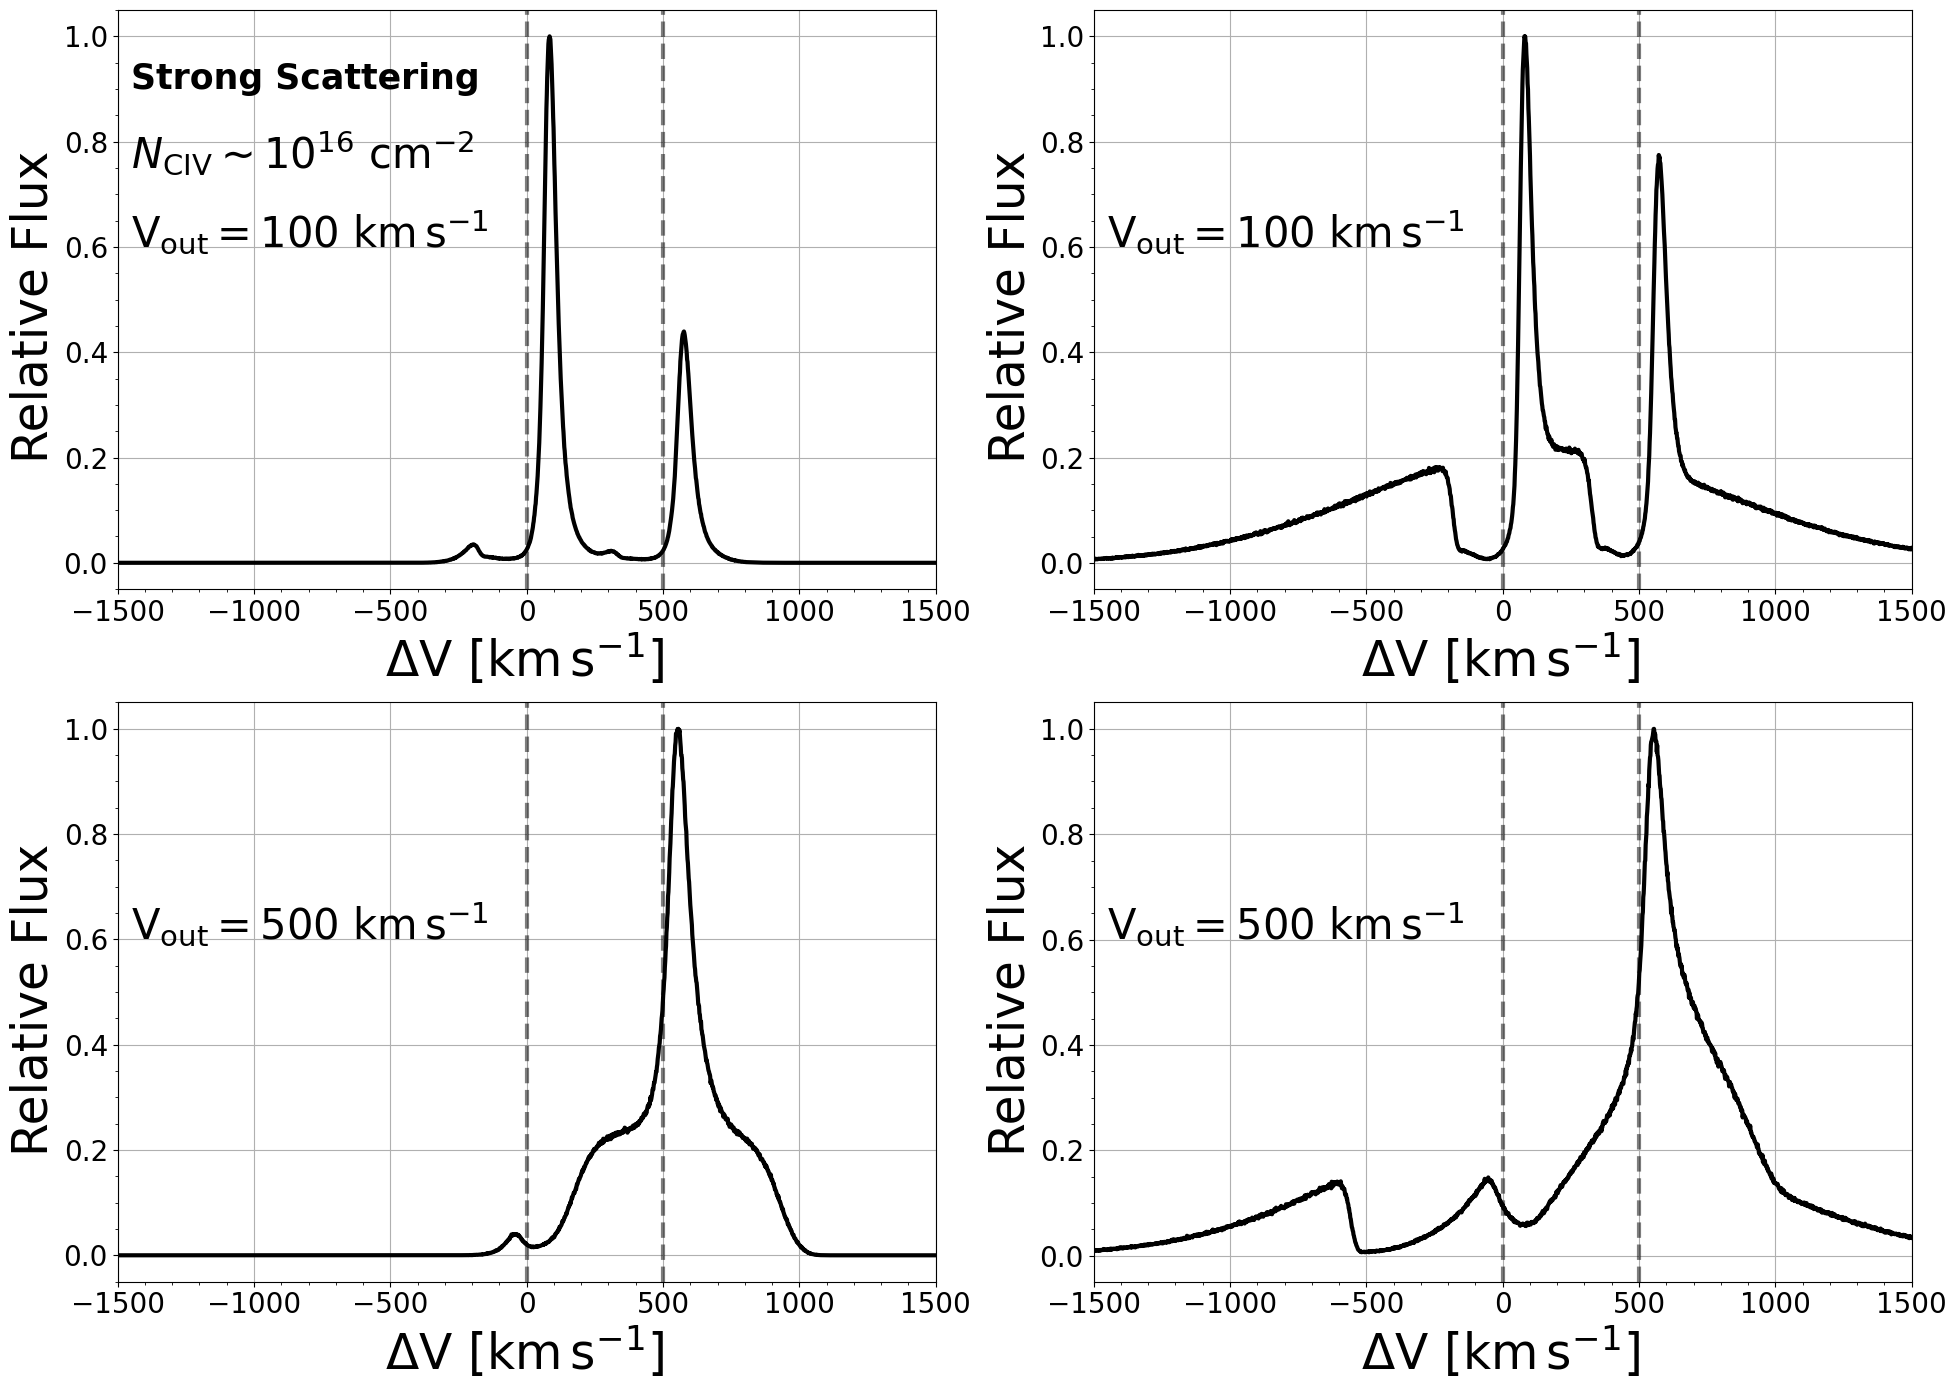

In [33]:
fig = plt.figure(1,figsize=(25,14))
index = 16
atom_num,vran = 10, 50

plt.subplot(221)
vout,vemit =  100, 100



normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')

plt.text(-1450,0.9,s='Strong Scattering',fontweight='bold',size=25)
plt.text(-1450,0.75,s=f'$N_{{\\rm CIV}} \\sim 10^{{{index}}}~{{\\rm cm^{{-2}}}}$',fontweight='bold',size=30)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)

plt.tight_layout()
plt.xlim(-1500,1500)

plt.subplot(222)
vout,vemit =  100, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)


plt.subplot(223)
vout,vemit =  500, 100

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)



plt.subplot(224)
vout,vemit =  500, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.xlim(-1500,1500)


# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_Mock_ss.pdf',bbox_inches="tight") 

Topping 2024 A1703-zd

0.8932863136712179


(-1500.0, 1500.0)

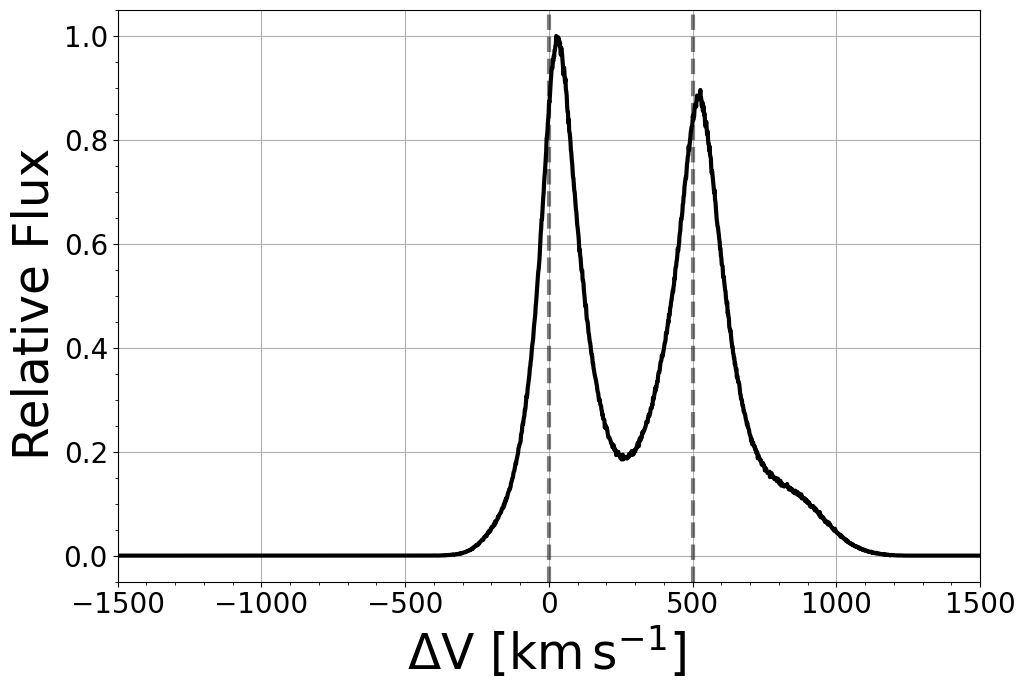

In [34]:
fig = plt.figure(1,figsize=(10,7))

atom_num,  vout,vemit,vran = 10, 700, 100, 50

# atom  = 13  # 13 - 20
# index = 15
# expand = 500 
# emit = 100 
# vrand = 50

index = 15

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
plt.xlim(-1500,1500)

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_example_AGN.pdf',bbox_inches="tight") 

Berg 2019b J104457 

1.9652073640505265


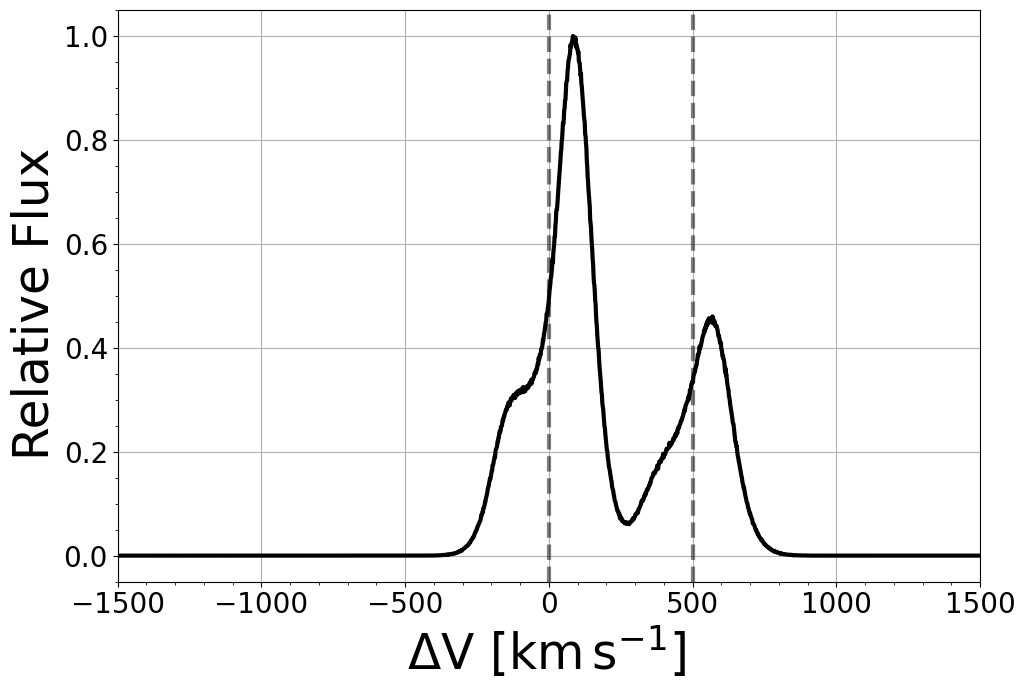

In [35]:
fig = plt.figure(1,figsize=(10,7))

atom_num,  vout,vemit,vran = 79, 100, 100, 100

# atom  = 13  # 13 - 20
# index = 15
# expand = 500 
# emit = 100 
# vrand = 50

index = 14

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
plt.xlim(-1500,1500)

plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_example_Berg_2.pdf',bbox_inches="tight") 

1.2739229328306503


(-1500.0, 1500.0)

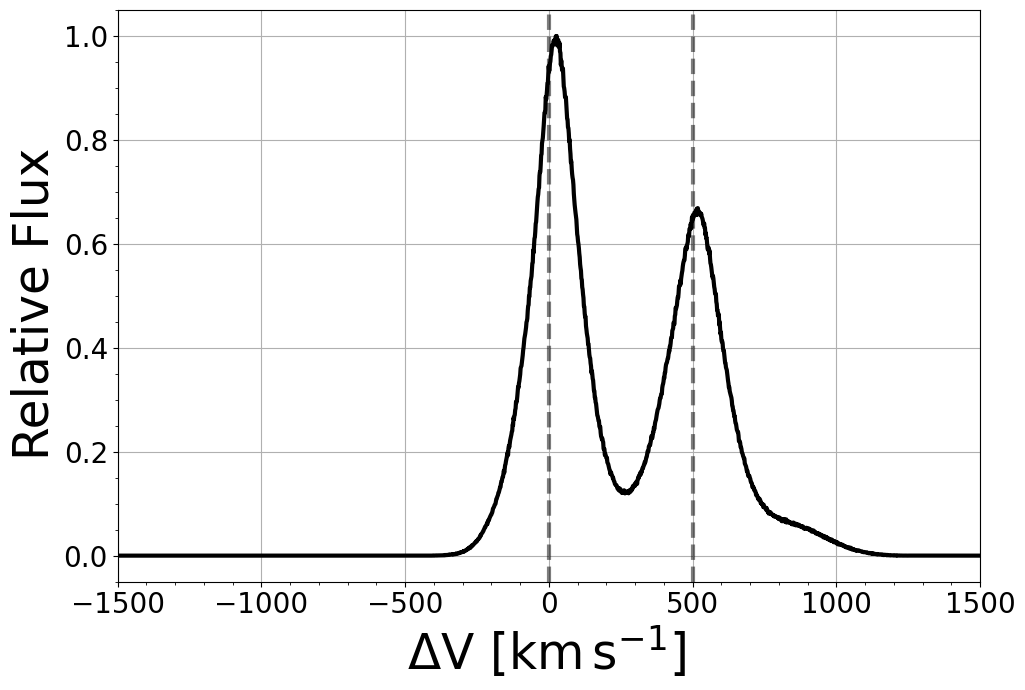

In [36]:
fig = plt.figure(1,figsize=(10,7))

atom_num,  vout,vemit,vran = 50, 700, 100, 50

# atom  = 13  # 13 - 20
# index = 15
# expand = 500 
# emit = 100 
# vrand = 50

index = 14

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
plt.xlim(-1500,1500)

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_example_AGN.pdf',bbox_inches="tight") 

0.811956006011625
0.706263334164989
0.7586752067921083
0.7938074403457227
0.6978149478353576
0.7508752768353966
0.7849632282081594
0.6952571779951549
0.7447236590774157


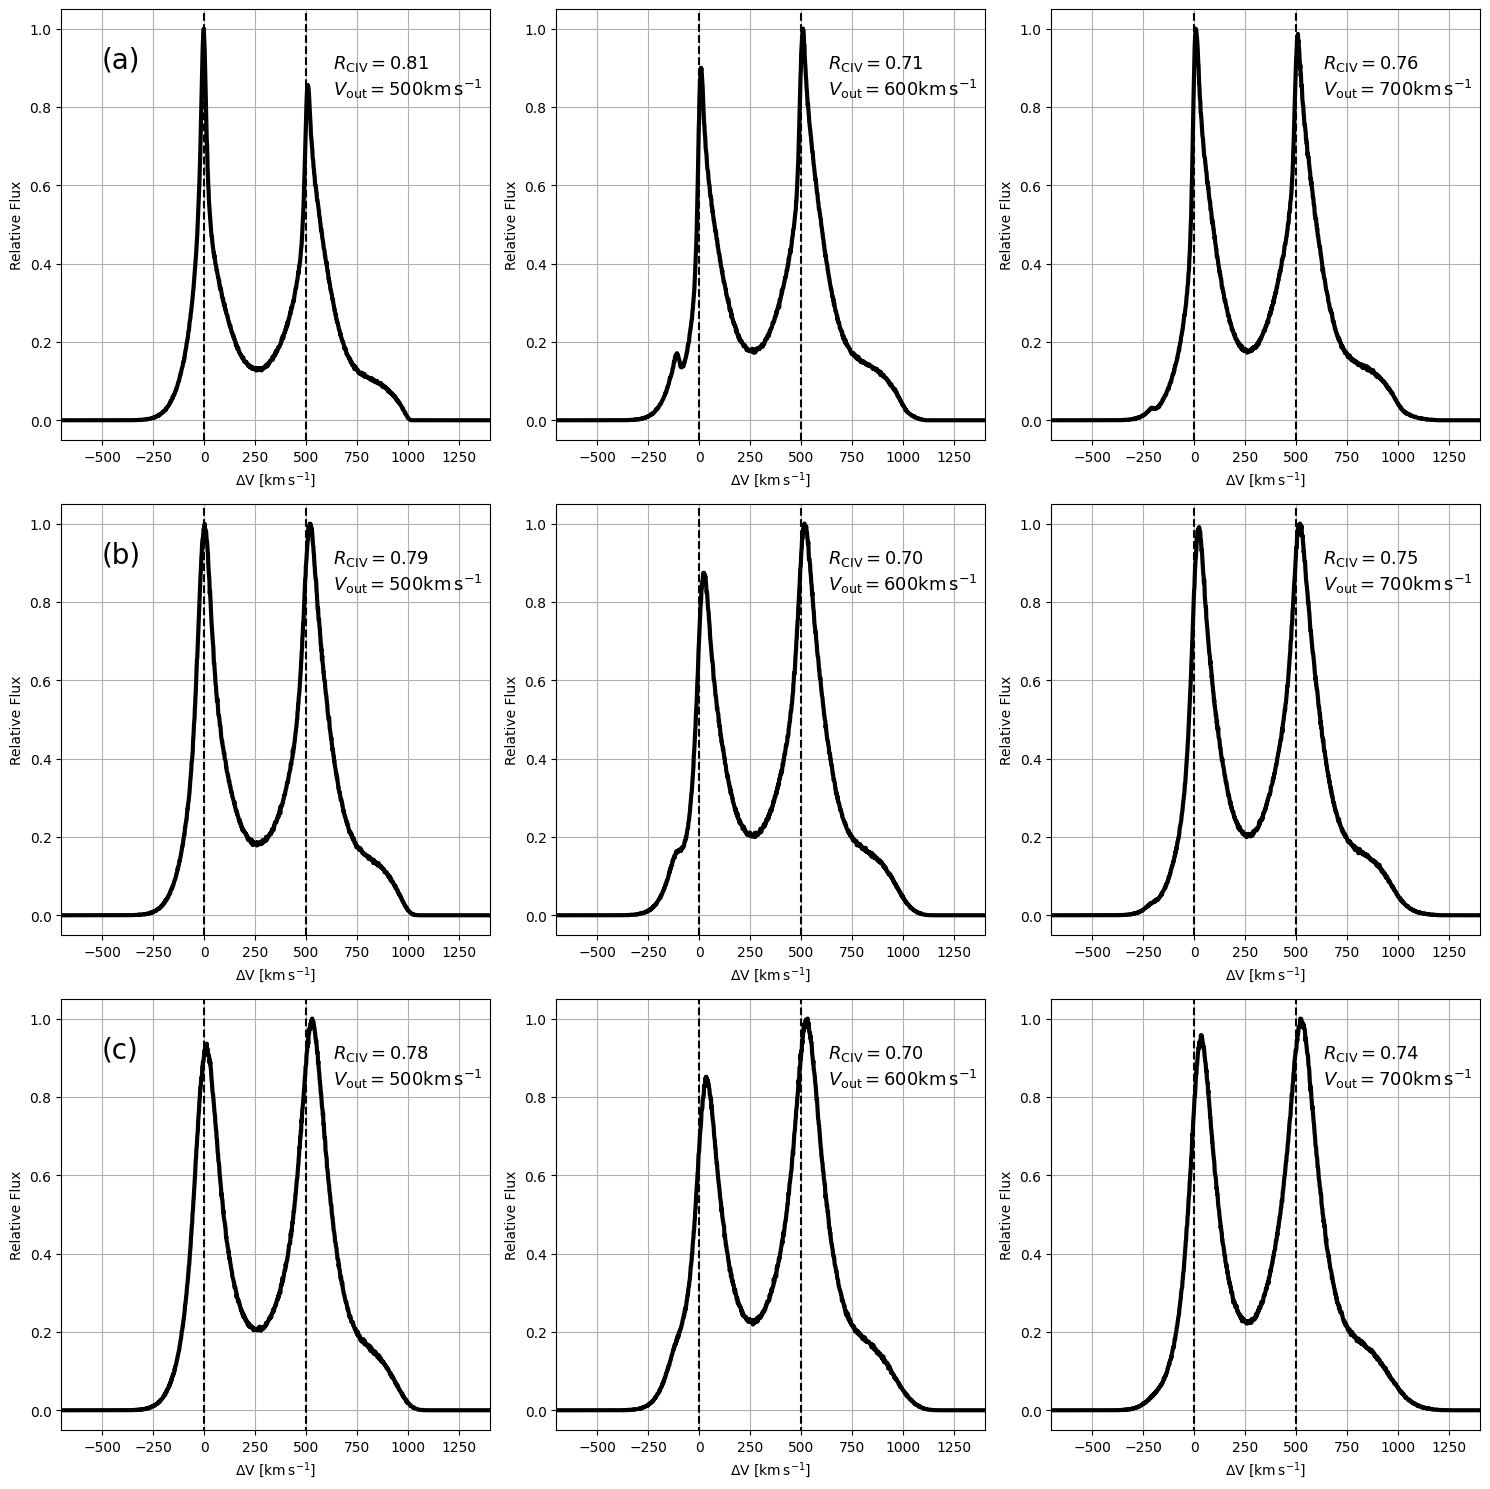

In [37]:


fig = plt.figure(1,figsize=(15,15))

plt.subplot(331)

atom_num  = 13  # 13 - 20
index = 15
vout = 500 
vemit = 100 
vran = 11.8

ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(-500, 0.9, '(a)',size=20)

plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()

plt.subplot(332)
vout = 600 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(333)
vout = 700 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()




vout = 500 
vemit = 100 
vran = 30

plt.subplot(334)
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(-500, 0.9, '(b)',size=20)

plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(335)
vout = 600 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(336)
vout = 700 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()




vout = 500 
vemit = 100 
vran = 50

plt.subplot(337)

vout = 500 
vemit = 100 
vran = 50
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(-500, 0.9, '(c)',size=20)

plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(338)
vout = 600 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()
plt.tight_layout()


plt.subplot(339)
vout = 700 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel(r'$\Delta \rm V ~ [\rm km\,s^{-1}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
plt.xlim(-700,1400)
plt.text(630, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(630, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)

plt.axvline(x=0,ymin=-1,ymax=10,linestyle='--',color='k')
plt.axvline(x=500,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()



# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Simulated_Spectrum_with_doublet_Ratio.pdf',bbox_inches='tight')

1.6864338182450884
1.6203664111747151
1.5040380186747941
1.6417606286065805
1.6846900325546734
1.6846900325546734
1.5343238193095048
1.624234744675474
1.6366187324436217


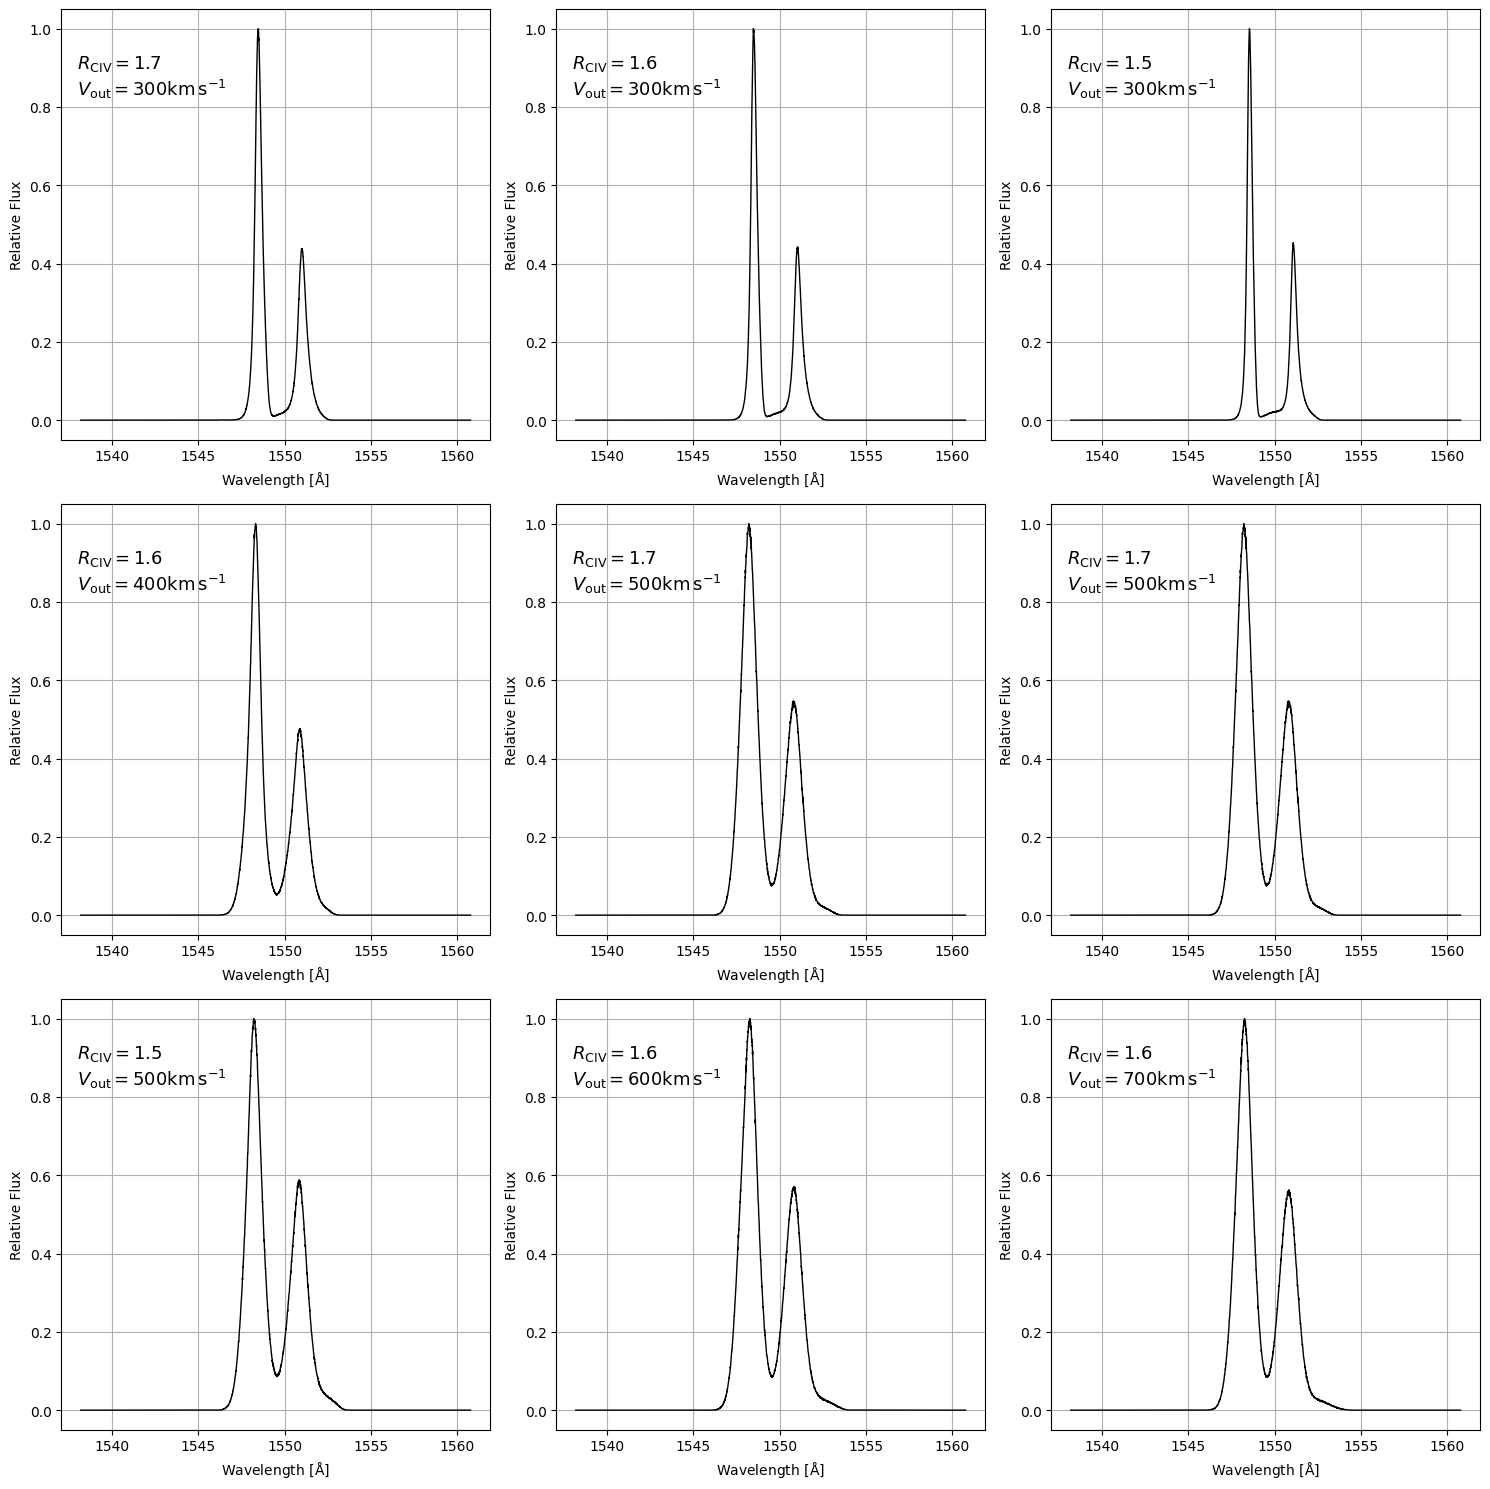

In [38]:

vemit = 100
vran = 50



fig = plt.figure(1,figsize=(15,15))

plt.subplot(331)

atom_num  = 32  # 13 - 20
index = 15
vout = 300 

ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
# plt.text(-500, 0.9, '(a)',size=20)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()

plt.subplot(332)
atom_num  = 50  # 13 - 20
index = 15
vout = 300 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
# plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {tot_ratio:.2f}$')

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(333)
atom_num  = 10  # 13 - 20
index = 16
vout = 300 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()







plt.subplot(334)
atom_num  = 50  # 13 - 20
index = 14
vout = 400 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
# plt.text(-500, 0.9, '(b)',size=20)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(335)
atom_num  = 20  # 13 - 20
index = 14
vout = 500 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(336)
atom_num  = 20 # 13 - 20
index = 14
vout = 500 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()



plt.subplot(337)
atom_num  = 32  # 13 - 20
index = 14
vout = 500 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
# plt.text(-500, 0.9, '(c)',size=20)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(338)
atom_num  = 20  # 13 - 20
index = 14
vout = 600 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()
plt.tight_layout()


plt.subplot(339)
atom_num  = 20  # 13 - 20
index = 14
vout = 700 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()



# plt.savefig(f'/home/jin/바탕화면/Spectra_Vrand_various.png',bbox_inches='tight')

0.9447157253622287
0.8932863136712179
1.2124810060776048


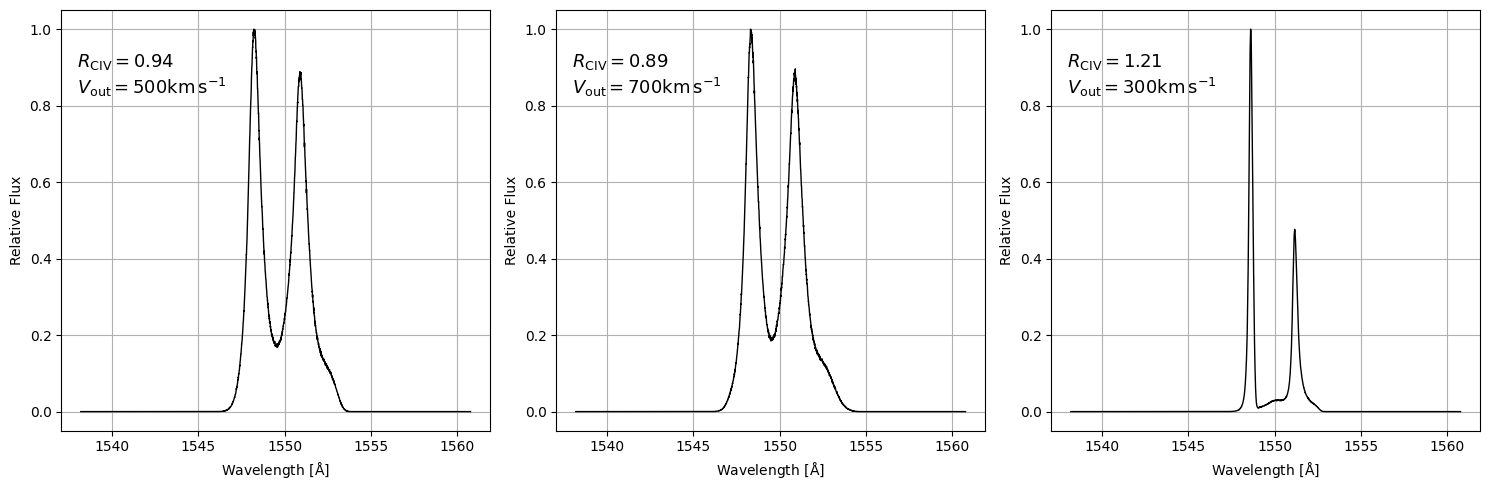

In [39]:
fig = plt.figure(1,figsize=(15,5))

plt.subplot(131)

atom_num  = 10  # 13 - 20
index = 15
vemit = 100
vran = 50

vout = 500 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
# plt.text(-500, 0.9, '(c)',size=20)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(132)
vout = 700 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)


# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()
plt.tight_layout()


plt.subplot(133)
atom_num  = 32
index = 16
vemit = 100
vran = 50
vout = 300 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()



0.8932863136712179
0.845431352963386


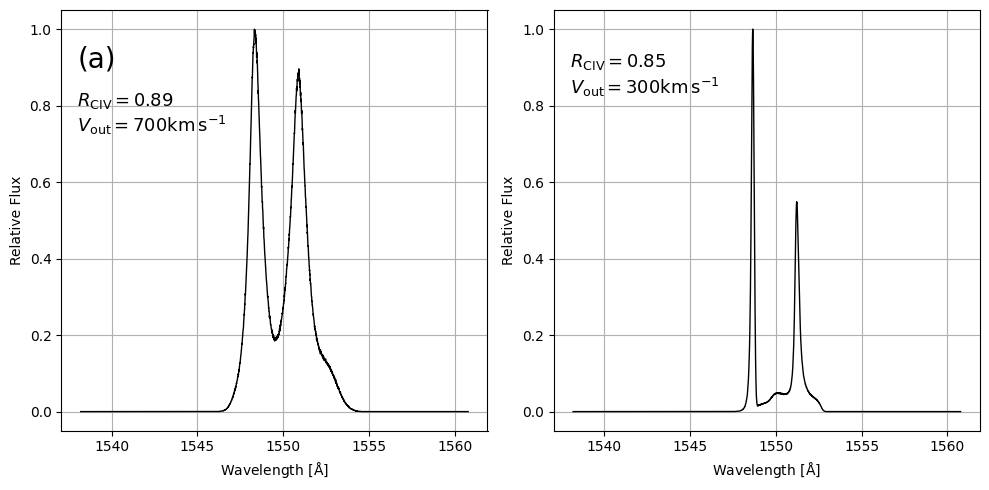

In [40]:
fig = plt.figure(1,figsize=(10,5))

plt.subplot(121)

atom_num  = 10  # 13 - 20
index = 15
vemit = 100
vran = 50

vout = 700 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.8, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(1538, 0.73, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(1538, 0.9, '(a)',size=20)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()


plt.subplot(122)
atom_num  = 79
index = 16
vemit = 100
vran = 50
vout = 300 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.2f}$',size=13)
plt.text(1538, 0.83, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)

# plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',color='k')
# plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',color='k')
plt.grid()
plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_different_profile.pdf',bbox_inches="tight") 

0.7849632282081594
0.8153773974041553
0.845431352963386


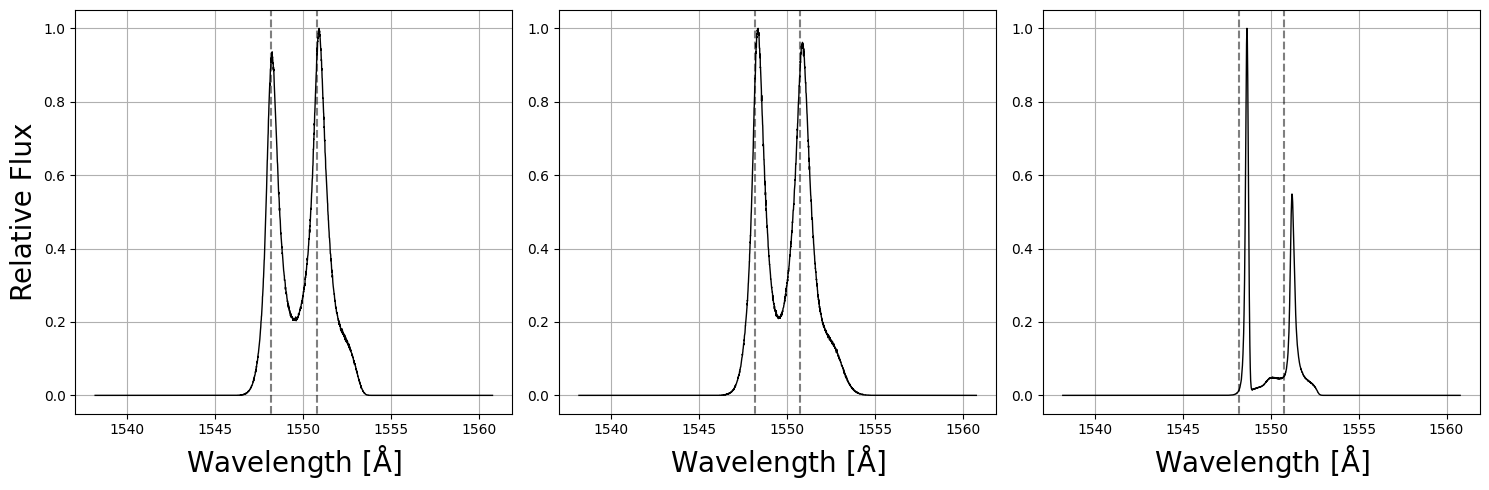

In [41]:
fig = plt.figure(1,figsize=(15,5))

plt.subplot(131)

atom_num  = 13  # 13 - 20
index = 15
vemit = 100
vran = 50

vout = 500 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=20)
plt.ylabel('Relative Flux',fontsize=20)
# plt.xlim(-700,1400)
# plt.text(1538, 0.8, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
# plt.text(1538, 0.73, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
# plt.text(1538, 0.9, '(a)',size=20)
# plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=15)
# plt.text(1538, 0.8, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=15)

plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',alpha=0.5,color='k')
plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',alpha=0.5,color='k')
plt.grid()
plt.tight_layout()


plt.subplot(132)
atom_num  = 13
index = 15
vemit = 100
vran = 50
vout = 800 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=20)
# plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
# plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=15)
# plt.text(1538, 0.8, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=15)

plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',alpha=0.5,color='k')
plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',alpha=0.5,color='k')
plt.grid()
plt.tight_layout()


plt.subplot(133)
atom_num  = 79
index = 16
vemit = 100
vran = 50
vout = 300 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=20)
# plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
# plt.text(1538, 0.9, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=15)
# plt.text(1538, 0.8, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=15)

plt.axvline(x=C_IV_K_A,ymin=-1,ymax=10,linestyle='--',alpha=0.5,color='k')
plt.axvline(x=C_IV_H_A,ymin=-1,ymax=10,linestyle='--',alpha=0.5,color='k')
plt.grid()
plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_different_profile.pdf',bbox_inches="tight") 

1.624234744675474
1.2609079018947962
0.8480247718991042
0.4823678116178231


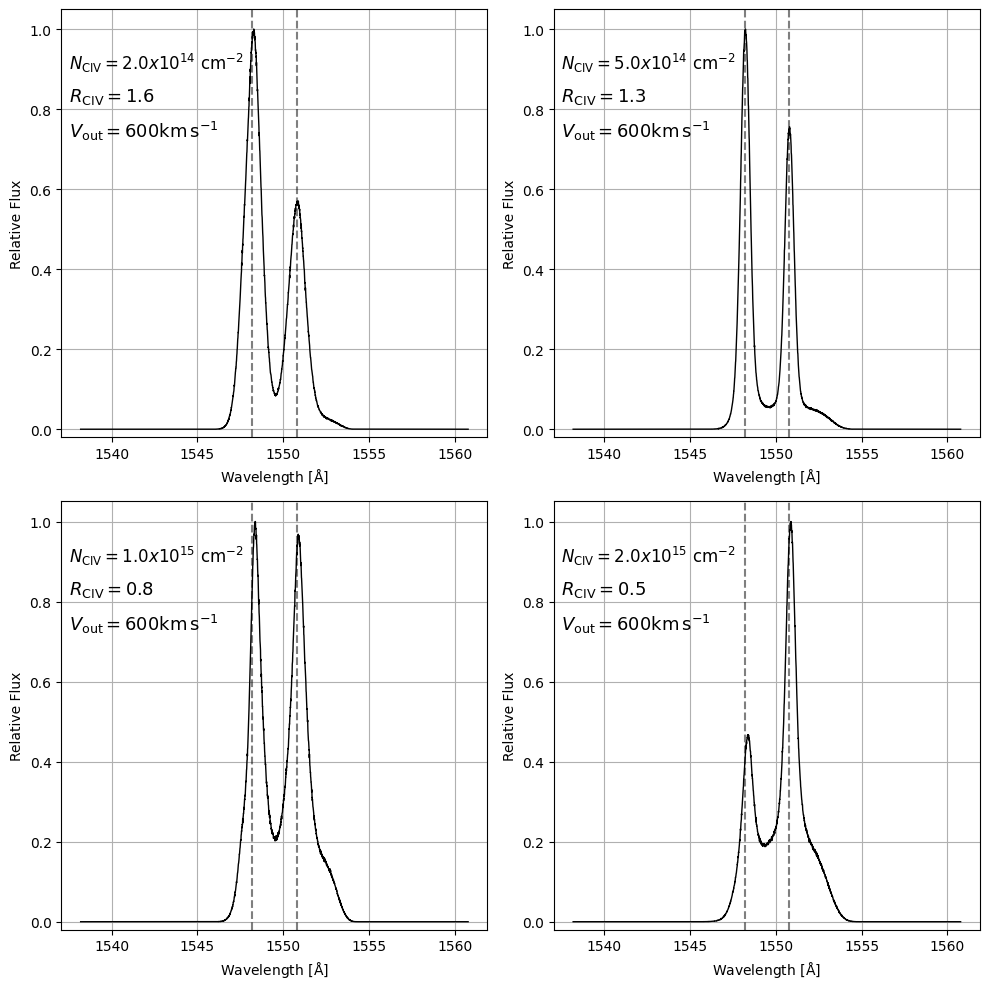

In [42]:
fig = plt.figure(1,figsize=(10,10))



plt.subplot(221)

atom_num  = 20 # 13 - 20
index = 14
vemit = 100

vout = 600 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1537.5, 0.82, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1537.5, 0.73, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(1537.5, 0.9, f'$N_{{\\rm CIV}} = {atom_num/10} x 10^{{{index}}}~\\rm cm^{{-2}}$',size=12)

plt.axvline(x=C_IV_K_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.axvline(x=C_IV_H_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.ylim(ymin=-0.02)

plt.grid()
plt.tight_layout()


plt.subplot(222)
# atom_num  = 79
# index = 16
atom_num  =50
index = 14
vemit = 50
vran = 100
vout = 600 

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1537.5, 0.82, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1537.5, 0.73, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(1537.5, 0.9, f'$N_{{\\rm CIV}} = {atom_num/10} x 10^{{{index}}}~\\rm cm^{{-2}}$',size=12)

plt.axvline(x=C_IV_K_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.axvline(x=C_IV_H_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.ylim(ymin=-0.02)
plt.grid()
plt.tight_layout()

# plt.savefig(f'/mnt/c/Use



plt.subplot(223)

atom_num  = 10 # 13 - 20
index = 15
vemit = 100
vran = 50

vout = 600 
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)
plt.text(1537.5, 0.82, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1537.5, 0.73, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(1537.5, 0.9, f'$N_{{\\rm CIV}} = {atom_num/10} x 10^{{{index}}}~\\rm cm^{{-2}}$',size=12)

plt.axvline(x=C_IV_K_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.axvline(x=C_IV_H_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.ylim(ymin=-0.02)
plt.grid()
plt.tight_layout()


plt.subplot(224)
# atom_num  = 79
# index = 16
atom_num  = 20
index = 15
vemit = 50
vran = 100
vout = 600
normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
ratio = doublet_ratio('all',atom_num,index, vout,vemit,vran)
plt.plot((K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=1,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))
plt.xlabel('Wavelength $[\\rm{\AA}]$',fontsize=10)
plt.ylabel('Relative Flux',fontsize=10)
# plt.xlim(-700,1400)

plt.text(1537.5, 0.82, f'$R_{{\\rm CIV}} = {ratio:.1f}$',size=13)
plt.text(1537.5, 0.73, f'$V_{{\\rm out}} = {vout} \\rm km\\,s^{{-1}}$',size=13)
plt.text(1537.5, 0.9, f'$N_{{\\rm CIV}} = {atom_num/10} x 10^{{{index}}}~\\rm cm^{{-2}}$',size=12)

plt.axvline(x=C_IV_K_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.axvline(x=C_IV_H_A,ymin=0,ymax=10,linestyle='--',color='k',alpha=0.5)
plt.ylim(ymin=-0.02)

plt.grid()
plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_different_profile.pdf',bbox_inches="tight") 

1.9652073640505265
1.2012216659517696


(-1500.0, 1500.0)

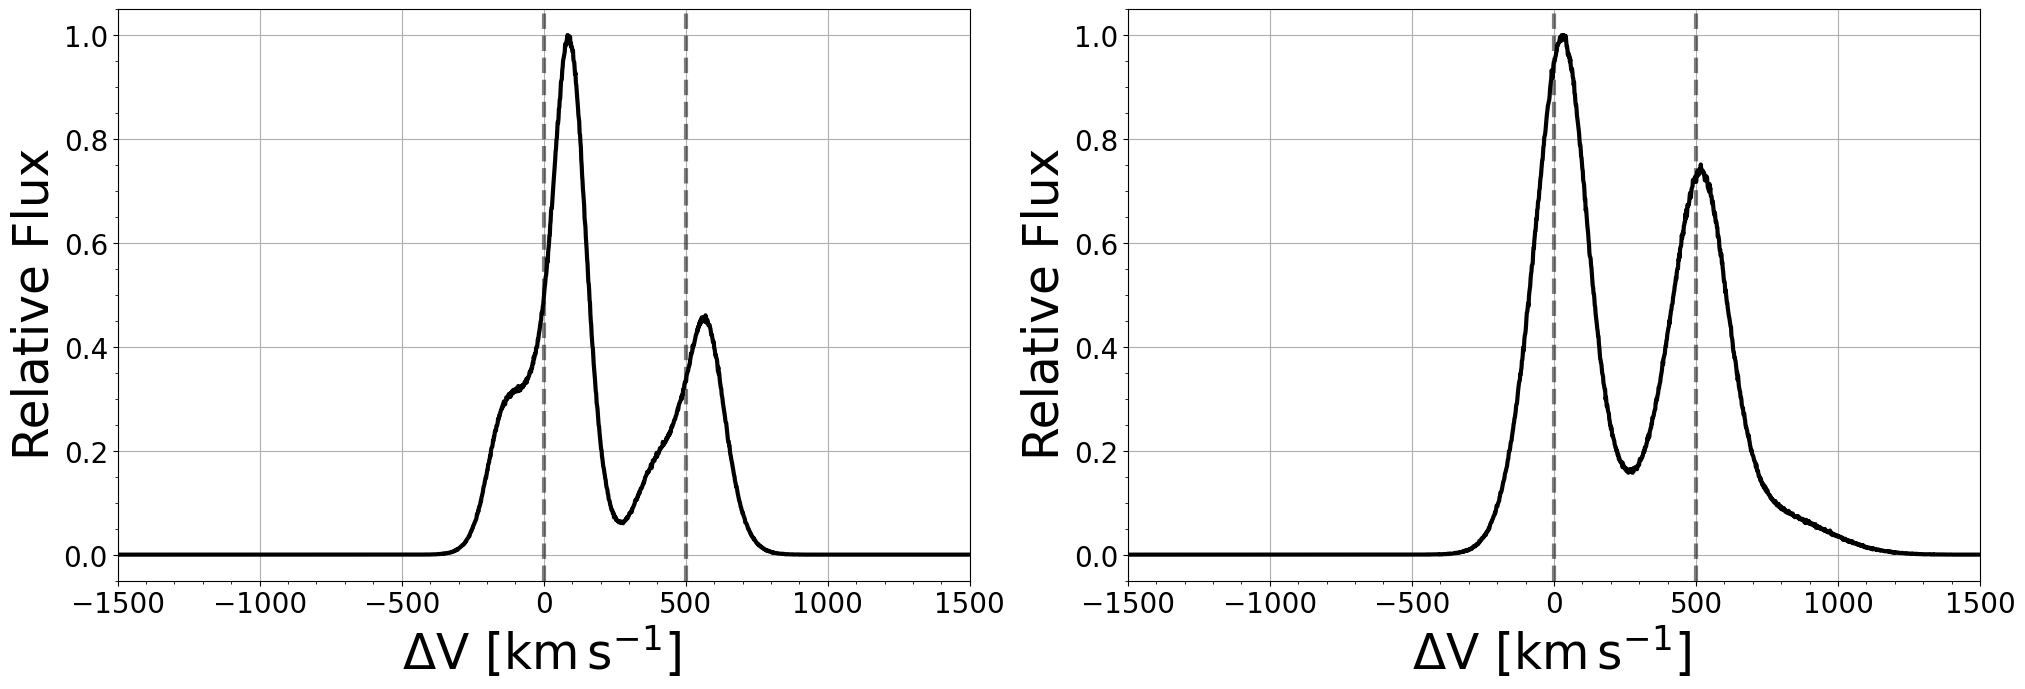

In [43]:
fig = plt.figure(1,figsize=(20,7))
plt.subplot(121)
atom_num,  vout,vemit,vran = 79, 100, 100, 100

# atom  = 13  # 13 - 20
# index = 15
# expand = 500 
# emit = 100 
# vrand = 50

index = 14

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
plt.xlim(-1500,1500)


plt.subplot(122)
atom_num,  vout,vemit,vran = 79, 1000, 100, 100

# atom  = 13  # 13 - 20
# index = 15
# expand = 500 
# emit = 100 
# vrand = 50

index = 14

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1.0,label=f'$10^{{{index}}}$')
print(doublet_ratio('all',atom_num,index, vout,vemit,vran))

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.text(50,3.5,s=r'V$_{\rm out}= 300~[\rm km\, s^{-1}]$',size=20)

plt.tight_layout()
plt.xlim(-1500,1500)



# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_example_Berg.pdf',bbox_inches="tight") 